# Time-Based Consolidation Strategies for Last-Mile Parcel Delivery

## Batch Delivery Day Optimisation — Region Hannover

**Bienzeisler et al. (2026)** — EWGT Conference Paper

---

This notebook implements a complete pipeline for evaluating time-based
consolidation (batch delivery) in urban last-mile logistics.  It covers
demand modelling, ML-based schedule optimisation, full VRP routing, and
iterative refinement of the machine-learned cost proxy.

| # | Section | Description |
| ---: | --- | --- |
| 1 | **Demand & Hub Network** | Load HAGRID demand, PLZ → hub assignment |
| 2 | **Baseline Routing** | Daily VRP via VROOM / Valhalla (6×/week) |
| 3 | **ML Cost Proxy** | MLP Ensemble predictor (44 features, 5 seeds) |
| 4 | **ML-SA Schedule Optimisation** | SA with ML proxy + fleet-balance post-processing |
| 5 | **Schedule Overview** | Animated heatmap of delivery patterns |
| 6 | **Scenario Routing** | 5 scenarios × 7 LSPs via VROOM (hash-cached) |
| 7 | **Results & KPIs** | Cost, load factor, fleet, waiting time comparison |
| 8 | **Iterative ML-SA Refinement** | Retrain ML → re-SA → re-route cycle |
| 9 | **Validation** | End-to-end checks across all 5 scenarios |

### References

- Jabali, O. et al. (2012). *A multi-vehicle covering tour problem.*
  Discrete Applied Mathematics.
- Beardwood, J. et al. (1959). *The shortest path through many points*
  (BHH constant). Mathematical Proceedings of the Cambridge Philosophical Society.

In [1]:
import sys, logging, warnings, importlib, time
sys.path.insert(0, str(__import__("pathlib").Path.cwd().parent / "src"))
warnings.filterwarnings("ignore", category=FutureWarning)

import numpy as np
import pandas as pd
from IPython.display import display, HTML
from tqdm.auto import tqdm
import lmd
from lmd import config, demand, hubs, optimization, routing, evaluation
from lmd.utils import log, compute_weighted_speed_factor, save_checkpoint, load_checkpoint
from lmd.config import (
    N_DAYS, WEEKDAYS, PROVIDERS,
    VEHICLE_CAPACITY, FIXED_COST_EUR,
    FAST_SHARE_B2C, FAST_SHARE_B2B,
    DATA_DIR, RESULTS_DIR,
    SC_BASELINE, SC_FIXED_EXPRESS, SC_FIXED_BATCH,
    SC_SA_ML_EXPRESS, SC_SA_ML_BATCH,
    SCENARIO_NAMES, NON_BASELINE_SCENARIOS, EXPRESS_SCENARIOS, BATCH_ONLY_SCENARIOS,
)

log.setLevel(logging.WARNING)

print(
    f"LMD Pipeline v{lmd.__version__}  |  "
    f"{len(PROVIDERS)} providers  |  "
    f"capacity {VEHICLE_CAPACITY}  |  "
    f"fixed cost {FIXED_COST_EUR:.0f} EUR/day  |  "
    f"express B2C {FAST_SHARE_B2C*100:.2f}% / B2B {FAST_SHARE_B2B*100:.2f}%  |  "
    f"{len(SCENARIO_NAMES)} scenarios"
)

c:\Users\bienzeisler\Documents\GitHub\vroom-valhalla-lmd-hannover\.venv\Lib\site-packages\tqdm\auto.py:21: TqdmWarning: IProgress not found. Please update jupyter and ipywidgets. See https://ipywidgets.readthedocs.io/en/stable/user_install.html
  from .autonotebook import tqdm as notebook_tqdm


LMD Pipeline v1.0.0  |  7 providers  |  capacity 230  |  fixed cost 189 EUR/day  |  express B2C 10.42% / B2B 5.00%  |  5 scenarios


## 1. Demand Data & Hub Network

Load the synthetic weekly HAGRID parcel demand (Monday–Saturday, 6 days)
for 7 logistics service providers in Region Hannover.  Each postal-code
area (PLZ) is assigned to the nearest KEP hub with capacity-aware
balancing.  Daily demand GeoDataFrames are reprojected to WGS-84 for
the VROOM / Valhalla routing engine.

**Checkpoint:** `01_demand`

In [2]:
# â”€â”€ Load demand and hub network for all providers â”€â”€â”€â”€â”€â”€â”€â”€â”€â”€â”€â”€â”€â”€â”€â”€â”€â”€â”€â”€â”€â”€â”€â”€â”€â”€
_ck = load_checkpoint("01_demand")
if _ck is not None:
    provider_data = _ck["provider_data"]
    gdf_plz = _ck["gdf_plz"]
    print(f"[checkpoint] Restored {len(provider_data)} providers")
else:
    gdf_plz = demand.load_plz_areas()
    provider_data = {}
    provider_rows = []

    pbar = tqdm(PROVIDERS, desc="Step 1 \u00b7 Loading providers", unit="lsp")
    for provider in pbar:
        daily_gdfs, plz_day_b2c, plz_day_b2b = demand.load_daily_demand(lsp_prefix=provider)
        gdf_provider = demand.build_unified_gdf(daily_gdfs)

        gdf_provider, plz_day_b2c, plz_day_b2b, merge_map = demand.merge_small_plz(
            gdf_provider, gdf_plz, plz_day_b2c, plz_day_b2b
        )
        all_plz_set = set(gdf_provider["plz"].unique()) - {"00000"}
        demand.fill_missing_days(all_plz_set, plz_day_b2c, plz_day_b2b)

        gdf_hubs = hubs.load_hubs(provider=provider)
        df_assignments = hubs.assign_plz_to_hubs(gdf_plz, gdf_hubs, all_plz_set)

        plz_demand, fast_share, weekday_shares = demand.compute_demand_stats(
            all_plz_set, plz_day_b2c, plz_day_b2b, df_assignments
        )
        daily_gdfs_wgs = demand.convert_daily_gdfs_to_wgs(daily_gdfs)

        weekly = int(plz_demand["weekly_parcels"].sum())
        pbar.set_postfix_str(f"{provider} \u2014 {weekly:,} p/wk, {len(all_plz_set)} PLZ")

        provider_data[provider] = {
            "daily_gdfs": daily_gdfs,
            "daily_gdfs_wgs": daily_gdfs_wgs,
            "gdf_provider": gdf_provider,
            "gdf_hubs": gdf_hubs,
            "df_assignments": df_assignments,
            "plz_day_b2c": plz_day_b2c,
            "plz_day_b2b": plz_day_b2b,
            "plz_demand": plz_demand,
            "all_plz_set": all_plz_set,
            "fast_share": fast_share,
            "weekday_shares": weekday_shares,
            "merge_map": merge_map,
        }

        provider_rows.append({
            "provider": provider,
            "plz": len(all_plz_set),
            "hubs": df_assignments["hub_name"].nunique(),
            "weekly_parcels": int(plz_demand["weekly_parcels"].sum()),
            "fast_share": round(fast_share * 100, 1),
        })

    df_provider_summary = pd.DataFrame(provider_rows).set_index("provider").sort_index()
    print("\u2500" * 72)
    display(df_provider_summary.style.format({
        "weekly_parcels": "{:,.0f}",
        "fast_share": "{:.1f}%",
    }))
    save_checkpoint("01_demand", provider_data=provider_data, gdf_plz=gdf_plz)

Step 1 · Loading providers: 100%|██████████| 7/7 [00:50<00:00,  7.24s/lsp, UPS — 115,649 p/wk, 40 PLZ]   

────────────────────────────────────────────────────────────────────────


,plz,hubs,weekly_parcels,fast_share
provider,,,,
Amazon,47,1,"227,677",10.4%
DHL,48,16,"516,034",9.8%
DPD,47,1,"102,540",9.3%
FedEx,37,1,"93,165",5.7%
GLS,46,1,"85,839",9.9%
Hermes,47,1,"122,226",10.3%
UPS,40,1,"115,649",6.0%


## 2. Baseline — Daily Delivery Routing (6×/week)

Build VROOM VRP requests for every PLZ on all 6 weekdays and solve them
using the Valhalla open-source routing engine.  Results are **SHA-256
hash-cached**: identical request bodies are never re-submitted.

The baseline represents today's standard practice — daily delivery to
every area — and serves as the cost reference for all subsequent
consolidation scenarios.

**Checkpoint:** `02_baseline`

In [3]:
# ── Build and solve provider-specific baseline VRPs ────────────────────────────
# Two-pass approach:
#   Pass 1 – Raw baseline (speed_factor=1.0, no traffic) → determine vehicle
#            activity patterns and derive a weighted speed factor (wsf).
#   Pass 2 – Re-solve baseline with wsf → realistic baseline including traffic.
_ck = load_checkpoint("02_baseline")
if _ck is not None:
    provider_data = _ck["provider_data"]
    baseline_job_caps = _ck["baseline_job_caps"]
    df_routes_baseline = _ck["df_routes_baseline"]
    baseline_solutions_by_provider = _ck["baseline_solutions_by_provider"]
    baseline_solve_by_provider = _ck["baseline_solve_by_provider"]
    wsf = _ck.get("wsf", 1.0)
    wtf = _ck.get("wtf", 0.0)
    print(f"[checkpoint] Restored baseline — {len(df_routes_baseline):,} routes  |  wsf={wsf:.3f}")
else:
    n_providers = len(provider_data)

    # ── Pass 1: Raw baseline (speed_factor=1.0, no traffic) ──────────────────
    print("Step 2a · Raw baseline (no traffic, speed_factor=1.0)")
    raw_routes_parts = []
    for i, (provider, pdata) in enumerate(provider_data.items(), 1):
        n_plz = len(pdata["all_plz_set"])
        print(f"  [{i}/{n_providers}] {provider} ({n_plz} PLZ × {N_DAYS} days)", flush=True)

        baseline_schedules = {pc: set(range(N_DAYS)) for pc in sorted(pdata["all_plz_set"])}

        raw_requests, _ = routing.build_scenario_requests(
            baseline_schedules,
            pdata["df_assignments"],
            pdata["daily_gdfs_wgs"],
            fast_share=1.0,
            speed_factor=1.0,
            scenario_name=f"{SC_BASELINE}_raw {provider}",
        )

        raw_solutions, _ = routing.solve_scenario(
            raw_requests,
            f"{SC_BASELINE}_raw {provider}",
            cache_tag=f"baseline_raw_{provider.lower()}",
            save_intermediate=RESULTS_DIR / "baseline" / f"{provider.lower()}_raw",
        )

        df_raw = routing.parse_routes(
            raw_solutions, SC_BASELINE, pdata["df_assignments"], provider_name=provider,
        )
        raw_routes_parts.append(df_raw)
        print(f"      {len(df_raw):,} routes | {df_raw['parcels'].sum():,.0f} parcels")

    df_routes_raw = pd.concat(raw_routes_parts, ignore_index=True)
    wtf, wsf = compute_weighted_speed_factor(df_routes_raw)
    print(f"\n  ➜ Weighted speed factor: {wsf:.3f}  (traffic factor {wtf:.4f})")

    # ── Pass 2: Traffic-adjusted baseline (speed_factor=wsf) ─────────────────
    print(f"\nStep 2b · Traffic baseline (speed_factor={wsf:.3f})")
    baseline_routes_parts = []
    baseline_solutions_by_provider = {}
    baseline_solve_by_provider = {}
    baseline_job_caps = {}

    for i, (provider, pdata) in enumerate(provider_data.items(), 1):
        n_plz = len(pdata["all_plz_set"])
        print(f"  [{i}/{n_providers}] {provider} ({n_plz} PLZ × {N_DAYS} days)", flush=True)

        baseline_schedules = {pc: set(range(N_DAYS)) for pc in sorted(pdata["all_plz_set"])}

        baseline_requests, df_baseline_summary = routing.build_scenario_requests(
            baseline_schedules,
            pdata["df_assignments"],
            pdata["daily_gdfs_wgs"],
            fast_share=1.0,
            speed_factor=wsf,
            scenario_name=f"{SC_BASELINE} {provider}",
        )

        baseline_solutions, df_baseline_solve = routing.solve_scenario(
            baseline_requests,
            f"{SC_BASELINE} {provider}",
            cache_tag=f"baseline_{provider.lower()}",
            save_intermediate=RESULTS_DIR / "baseline" / provider.lower(),
        )

        df_routes_provider = routing.parse_routes(
            baseline_solutions,
            SC_BASELINE,
            pdata["df_assignments"],
            provider_name=provider,
        )

        pdata["baseline_schedules"] = baseline_schedules
        pdata["baseline_routes"] = df_routes_provider
        pdata["baseline_solutions"] = baseline_solutions
        pdata["baseline_solve"] = df_baseline_solve
        baseline_solutions_by_provider[provider] = baseline_solutions
        baseline_solve_by_provider[provider] = df_baseline_solve
        baseline_routes_parts.append(df_routes_provider)

        caps = routing.compute_baseline_job_caps(baseline_solutions)
        baseline_job_caps[provider] = caps
        print(
            f"      {len(df_routes_provider):,} routes | "
            f"{df_routes_provider['parcels'].sum():,.0f} parcels | "
            f"{df_routes_provider['distance_km'].sum():,.0f} km"
        )

    df_routes_baseline = pd.concat(baseline_routes_parts, ignore_index=True)
    print(
        "\u2500" * 72 + "\n"
        f"Baseline complete  |  "
        f"{len(df_routes_baseline):,} routes  |  "
        f"{df_routes_baseline['parcels'].sum():,.0f} parcels  |  "
        f"{df_routes_baseline['distance_km'].sum():,.0f} km  |  "
        f"wsf={wsf:.3f}"
    )
    save_checkpoint(
        "02_baseline",
        provider_data=provider_data,
        baseline_job_caps=baseline_job_caps,
        df_routes_baseline=df_routes_baseline,
        baseline_solutions_by_provider=baseline_solutions_by_provider,
        baseline_solve_by_provider=baseline_solve_by_provider,
        wsf=wsf,
        wtf=wtf,
    )

Step 2a · Raw baseline (no traffic, speed_factor=1.0)
  [1/7] DHL (48 PLZ × 6 days)


      2,317 routes | 497,643 parcels
  [2/7] Amazon (47 PLZ × 6 days)


      1,089 routes | 217,577 parcels
  [3/7] DPD (47 PLZ × 6 days)


      569 routes | 97,609 parcels
  [4/7] FedEx (37 PLZ × 6 days)


      439 routes | 77,383 parcels
  [5/7] GLS (46 PLZ × 6 days)


...

      569 routes | 97,197 parcels | 42,230 km
  [4/7] FedEx (37 PLZ × 6 days)


      439 routes | 77,296 parcels | 27,854 km
  [5/7] GLS (46 PLZ × 6 days)


      469 routes | 80,208 parcels | 37,089 km
  [6/7] Hermes (47 PLZ × 6 days)


      661 routes | 116,770 parcels | 41,139 km
  [7/7] UPS (40 PLZ × 6 days)


      556 routes | 100,906 parcels | 31,833 km
────────────────────────────────────────────────────────────────────────
Baseline complete  |  6,100 routes  |  1,187,462 parcels  |  290,665 km  |  wsf=0.814


In [4]:
# ── Speed factor (already computed during two-pass baseline above) ────────────
print(f"Speed factor {wsf:.3f}  (traffic factor {wtf:.4f}, config default {config.SPEED_FACTOR})")

Speed factor 0.814  (traffic factor 1.2284, config default 0.819)


## 3. ML Cost Proxy — MLP Ensemble

Instead of the classical Daganzo continuous-approximation formula, this
pipeline uses a **production MLP Ensemble** as the VRP cost function
inside simulated annealing.  The ensemble averages 5 separately-seeded
MLPRegressor pipelines, each trained on 44 composite features (25 base
+ 8 interaction terms + 11 log-transforms) against VROOM per-PLZ-day
costs.

| Property | Value |
| --- | --- |
| Architecture | `(512, 512, 256, 128)` |
| Seeds | `42, 123, 456, 789, 2024` |
| Validation MAPE (CV) | ≈ 5 % |

### 3.1 Prepare Optimisation Data & Train Initial ML Model

1. Build per-provider `optimization_data` (PLZ data, schedules, hub arrays)
2. Precompute per-PLZ-day coordinates and hub assignments for ML features
3. Build a feature matrix from **baseline-only** routes
4. Train the initial MLP Ensemble on this baseline data

**Checkpoints:** `04_optim_prep`, `07_ml_predictor`


In [ ]:
# ═══════════════════════════════════════════════════════════════════════════
# §3.1  Prepare optimisation data & train initial ML model
# ═══════════════════════════════════════════════════════════════════════════

importlib.reload(demand)
importlib.reload(config)
importlib.reload(optimization)

from lmd.ml_cost import MLCostPredictor
from lmd.features import build_feature_matrix, ALL_COLS
from lmd.optimization import (
    enumerate_valid_schedules,
    build_cost_matrices_ml, optimize_cd_ml, balance_fleet_per_hub_ml,
    build_fixed_schedules, build_hub_arrays,
)
from lmd.config import provider_to_demand_prefix

log.setLevel(logging.INFO)

# ── 1. Build per-provider optimisation data ───────────────────────────────
_ck = load_checkpoint("04_optim_prep")
if _ck is not None:
    optimization_data = _ck["optimization_data"]
    print(f"[checkpoint] Restored optimisation prep for {len(optimization_data)} providers")
else:
    optimization_data = {}
    prep_rows = []

    pbar = tqdm(provider_data.items(), desc="§3 · Preparing optimisation", unit="lsp")
    for provider, pdata in pbar:
        plz_data = demand.prepare_plz_data(
            pdata["all_plz_set"],
            pdata["df_assignments"],
            gdf_plz,
            pdata["gdf_provider"],
            pdata["daily_gdfs_wgs"],
            pdata["plz_day_b2c"],
            pdata["plz_day_b2b"],
        )
        plz_keys = sorted(plz_data.keys())
        schedules = enumerate_valid_schedules()
        plz_hub_arr, hub_plz_list, hub_names = build_hub_arrays(
            plz_keys, pdata["df_assignments"],
        )

        pbar.set_postfix_str(f"{provider} — {len(plz_keys)} PLZ × {len(schedules)} schedules")

        optimization_data[provider] = {
            "plz_data": plz_data,
            "plz_keys": plz_keys,
            "schedules": schedules,
            "plz_hub_arr": plz_hub_arr,
            "hub_plz_list": hub_plz_list,
            "hub_names": hub_names,
        }
        prep_rows.append({"provider": provider, "plz": len(plz_keys),
                          "schedules": len(schedules), "hubs": len(hub_names)})

    df_optim_prep = pd.DataFrame(prep_rows).set_index("provider").sort_index()
    print("\u2500" * 72)
    display(df_optim_prep)
    save_checkpoint("04_optim_prep", optimization_data=optimization_data)

# ── 2. Build plz_day_coords and hub_coords_by_plz per provider ───────────
ml_prep = {}
for provider in PROVIDERS:
    pdata = provider_data[provider]
    odata = optimization_data[provider]

    hub_coords_by_plz = {}
    for _, hr in pdata["df_assignments"].iterrows():
        hub_coords_by_plz[hr["plz"]] = (hr["hub_lon"], hr["hub_lat"])

    prefix = provider_to_demand_prefix(provider)
    col_total = f"{prefix}_total"
    daily_wgs = pdata["daily_gdfs_wgs"]
    plz_day_coords: dict = {}

    for plz_code in odata["plz_keys"]:
        plz_day_coords[plz_code] = {}
        for d in range(N_DAYS):
            gdf_d = daily_wgs.get(d)
            if gdf_d is None:
                continue
            pts = gdf_d[gdf_d["plz"] == plz_code]
            if len(pts) == 0:
                continue
            lons = pts["lon"].values.astype(np.float64)
            lats = pts["lat"].values.astype(np.float64)
            psd = (
                pts[col_total].values.astype(np.float64)
                if col_total in pts.columns
                else np.ones(len(pts))
            )
            plz_day_coords[plz_code][d] = (lons, lats, psd)

    ml_prep[provider] = {
        "plz_day_coords": plz_day_coords,
        "hub_coords_by_plz": hub_coords_by_plz,
    }
    print(f"  {provider}: {len(plz_day_coords)} PLZ, "
          f"{len(hub_coords_by_plz)} hub assignments")

# ── 3. Train initial ML model from baseline routes ───────────────────────
# Baseline schedules: every PLZ delivers every day
baseline_sched_by_provider = {}
for provider in PROVIDERS:
    baseline_sched_by_provider[provider] = {
        SC_BASELINE: {pc: set(range(N_DAYS)) for pc in optimization_data[provider]["plz_keys"]}
    }

baseline_routes_dict = {SC_BASELINE: df_routes_baseline}

ck_ml = load_checkpoint("07_ml_predictor")
if ck_ml is not None:
    ml_predictor = ck_ml["ml_predictor"]
    print(f"\n[checkpoint] ML predictor loaded: {len(ml_predictor.pipelines)} pipelines, "
          f"{len(ml_predictor.combo_cols)} combo features")
else:
    print("\n§3 · Training initial ML model from baseline routes ...")
    t0_ml = time.perf_counter()

    df_train = build_feature_matrix(
        provider_data=provider_data,
        optimization_data=optimization_data,
        cal_by_provider=None,
        all_routes=baseline_routes_dict,
        scenario_schedules_by_provider=baseline_sched_by_provider,
        gdf_plz=gdf_plz,
        providers=list(PROVIDERS),
        scenarios=[SC_BASELINE],
        tier=3,
    )
    X_train = df_train[ALL_COLS].copy()
    y_train = df_train["actual_cost"].values
    print(f"  Feature matrix: {len(df_train):,} rows \u00d7 {X_train.shape[1]} features")

    ml_predictor = MLCostPredictor.train(
        X_train, y_train,
        alpha=0.001,
        arch=(512, 512, 256, 128),
    )

    pred = ml_predictor.predict(X_train)
    mape = np.mean(np.abs((y_train - pred) / np.clip(y_train, 1, None))) * 100
    r2 = 1 - np.sum((y_train - pred) ** 2) / np.sum((y_train - y_train.mean()) ** 2)
    dt = time.perf_counter() - t0_ml

    print(f"  Initial ML model trained in {dt:.0f}s")
    print(f"  Train MAPE = {mape:.2f}%,  R\u00b2 = {r2:.4f}")

    save_checkpoint("07_ml_predictor", ml_predictor=ml_predictor)
    ml_predictor.save(RESULTS_DIR / "checkpoints" / "ml_predictor.pkl")
    print(f"  Saved checkpoint 07_ml_predictor")


## 4. ML-SA Schedule Optimisation

Determine which days each PLZ should receive deliveries to minimise
total weekly cost under a maximum-gap constraint (≤ 2 holding days).

**Step 1 — Simulated Annealing** with the MLP Ensemble cost proxy.
Each PLZ is assigned one of 494 valid weekly schedules (2–6 days).
SA minimises the sum of ML-predicted delivery-day costs and hub-bundled
express costs (500 k iterations, $T_0 = 5\,000$, $\alpha = 0.99998$).

**Step 2 — Fleet Balancing.** Swap-based post-processing equalises
daily vehicle counts per hub, allowing up to 1 % cost increase.

Both **Express** and **Batch-Only** variants are computed.  The Fixed
schedules (carrier-specific) are deterministic and serve as the
comparison baseline.

**Checkpoint:** `08_sa_ml_optimization`

In [ ]:
# ═══════════════════════════════════════════════════════════════════════════
# §4  ML-CD Schedule Optimisation (Coordinate Descent) — Express + Batch-Only
# ═══════════════════════════════════════════════════════════════════════════

# Initialise scenario_schedules_by_provider with baseline (all-day) schedules
scenario_schedules_by_provider = {}
for provider in PROVIDERS:
    baseline_sched = {
        pc: set(range(N_DAYS)) for pc in optimization_data[provider]["plz_keys"]
    }
    scenario_schedules_by_provider[provider] = {
        SC_BASELINE: baseline_sched,
    }

_ck = load_checkpoint("08_sa_ml_optimization")
if _ck is not None:
    for p in PROVIDERS:
        scenario_schedules_by_provider[p].update(_ck["ml_schedules"][p])
    ml_optimization_data = _ck["ml_optimization_data"]
    print(f"[checkpoint] Restored SA_ML optimisation for {len(PROVIDERS)} providers")
else:
    ml_optimization_data = {}
    ml_optim_rows = []
    n_providers = len(PROVIDERS)

    print("Step 4 \u00b7 ML-SA optimisation")
    for i, provider in enumerate(PROVIDERS, 1):
        odata = optimization_data[provider]
        prep = ml_prep[provider]
        plz_keys = odata["plz_keys"]
        schedules = odata["schedules"]
        n_plz = len(plz_keys)
        print(f"  [{i}/{n_providers}] {provider} ({n_plz} PLZ)", flush=True)

        # ── Build Fixed schedules (deterministic) ──────────────────────────
        fixed_schedules = build_fixed_schedules(plz_keys, carrier=provider)
        fixed_batch_schedules = build_fixed_schedules(plz_keys, carrier=provider)

        # Build fixed assignment array for SA initialisation
        _sched_to_idx = {s: si for si, s in enumerate(schedules)}
        _fixed_asn = np.array([
            _sched_to_idx.get(
                frozenset(fixed_schedules.get(pk, set(range(N_DAYS)))), 0
            )
            for pk in plz_keys
        ], dtype=np.intp)

        # ── Build ML cost matrices ─────────────────────────────────────────
        matrices_ml_expr = build_cost_matrices_ml(
            plz_keys, odata["plz_data"], schedules, ml_predictor,
            provider, prep["plz_day_coords"], prep["hub_coords_by_plz"],
            fast_share_b2c=FAST_SHARE_B2C,
            fast_share_b2b=FAST_SHARE_B2B,
        )
        matrices_ml_batch = build_cost_matrices_ml(
            plz_keys, odata["plz_data"], schedules, ml_predictor,
            provider, prep["plz_day_coords"], prep["hub_coords_by_plz"],
            fast_share_b2c=0.0, fast_share_b2b=0.0,
        )

        # ── SA + fleet balance: Express ────────────────────────────────────
        sa_ml_expr = optimize_cd_ml(
            plz_keys, odata["plz_hub_arr"], odata["hub_plz_list"],
            matrices_ml_expr, schedules, batch_only=False,
            fixed_assignment=_fixed_asn,
        )
        bal_ml_expr = balance_fleet_per_hub_ml(
            sa_ml_expr, plz_keys, odata["plz_hub_arr"],
            odata["hub_plz_list"], matrices_ml_expr, schedules,
        )

        # ── SA + fleet balance: Batch-Only ─────────────────────────────────
        sa_ml_batch = optimize_cd_ml(
            plz_keys, odata["plz_hub_arr"], odata["hub_plz_list"],
            matrices_ml_batch, schedules, batch_only=True,
            fixed_assignment=_fixed_asn,
        )
        bal_ml_batch = balance_fleet_per_hub_ml(
            sa_ml_batch, plz_keys, odata["plz_hub_arr"],
            odata["hub_plz_list"], matrices_ml_batch, schedules,
        )

        # ── Store schedules ────────────────────────────────────────────────
        scenario_schedules_by_provider[provider][SC_FIXED_EXPRESS] = fixed_schedules
        scenario_schedules_by_provider[provider][SC_SA_ML_EXPRESS] = \
            bal_ml_expr["schedules_per_plz"]
        scenario_schedules_by_provider[provider][SC_FIXED_BATCH] = fixed_batch_schedules
        scenario_schedules_by_provider[provider][SC_SA_ML_BATCH] = \
            bal_ml_batch["schedules_per_plz"]

        ml_optimization_data[provider] = {
            "matrices_ml_expr": matrices_ml_expr,
            "matrices_ml_batch": matrices_ml_batch,
            "sa_ml_expr": sa_ml_expr,
            "bal_ml_expr": bal_ml_expr,
            "sa_ml_batch": sa_ml_batch,
            "bal_ml_batch": bal_ml_batch,
            "fixed_schedules": fixed_schedules,
            "fixed_batch_schedules": fixed_batch_schedules,
        }

        print(f"      ML+Express  {bal_ml_expr['cost']:,.0f} EUR / "
              f"ML Batch  {bal_ml_batch['cost']:,.0f} EUR")

        ml_optim_rows.extend([
            {"provider": provider, "scenario": SC_SA_ML_EXPRESS,
             "cost_eur": round(bal_ml_expr["cost"], 0),
             "swaps": bal_ml_expr["swaps_made"],
             "imbalance_before": round(bal_ml_expr["imbalance_before"], 1),
             "imbalance_after": round(bal_ml_expr["imbalance_after"], 1)},
            {"provider": provider, "scenario": SC_SA_ML_BATCH,
             "cost_eur": round(bal_ml_batch["cost"], 0),
             "swaps": bal_ml_batch["swaps_made"],
             "imbalance_before": round(bal_ml_batch["imbalance_before"], 1),
             "imbalance_after": round(bal_ml_batch["imbalance_after"], 1)},
        ])

    df_ml_optim = pd.DataFrame(ml_optim_rows)
    print("\u2500" * 72)
    display(df_ml_optim.style.format({
        "cost_eur": "{:,.0f}",
        "imbalance_before": "{:.1f}",
        "imbalance_after": "{:.1f}",
    }))

    save_checkpoint(
        "08_sa_ml_optimization",
        ml_schedules={
            p: {
                SC_SA_ML_EXPRESS: scenario_schedules_by_provider[p][SC_SA_ML_EXPRESS],
                SC_SA_ML_BATCH: scenario_schedules_by_provider[p][SC_SA_ML_BATCH],
            }
            for p in PROVIDERS
        },
        ml_optimization_data=ml_optimization_data,
    )


## 5. Delivery Schedule Overview

Interactive animated visualisation of the optimised delivery schedules.
The heatmap shows the percentage of PLZ areas receiving deliveries on
each weekday under every scenario.  The frequency chart reveals how
batch consolidation shifts from daily (6×/week) to reduced frequencies
(2–3×/week).

Use **▶ Play** to animate through scenarios, or drag the slider.

In [8]:
# â”€â”€ Interactive schedule overview â”€â”€â”€â”€â”€â”€â”€â”€â”€â”€â”€â”€â”€â”€â”€â”€â”€â”€â”€â”€â”€â”€â”€â”€â”€â”€â”€â”€â”€â”€â”€â”€â”€â”€â”€â”€â”€â”€â”€â”€â”€â”€â”€
fig_schedule = evaluation.plot_schedule_overview(
    scenario_schedules_by_provider,
    PROVIDERS, SCENARIO_NAMES, WEEKDAYS[:N_DAYS],
)
fig_schedule.show()

## 6. VROOM Routing — All Scenarios

Solve VRP instances for all 5 scenarios using VROOM with SHA-256 hash
caching.  Express scenarios include hub-bundled express routes on
non-delivery days.  Each provider × scenario combination produces a set
of routes that are parsed into a unified DataFrame.

**Demand conservation:** Express parcels delivered on non-delivery days
are subtracted from the next delivery day's accumulated demand, so every
parcel is counted exactly once.

**Checkpoint:** `06_scenario_routing`

In [9]:
# â”€â”€ Reload routing module after code changes â”€â”€â”€â”€â”€â”€â”€â”€â”€â”€â”€â”€â”€â”€â”€â”€â”€â”€â”€â”€â”€â”€â”€â”€â”€â”€â”€â”€â”€â”€â”€
importlib.reload(routing)
log.setLevel(logging.DEBUG)  # show Valhalla memory in day summaries
print(f"routing module reloaded â€” Valhalla memory limit: {routing._VALHALLA_MEM_LIMIT_MB} MB")

routing module reloaded â€” Valhalla memory limit: 20000 MB


In [ ]:
# ── Solve VRPs for all non-baseline scenarios ─────────────────────────────
_ck = load_checkpoint("06_scenario_routing")
if _ck is not None:
    all_routes = _ck["all_routes"]
    all_solutions_by_provider = _ck["all_solutions_by_provider"]
    df_solve_summary = _ck["df_solve_summary"]
    print(f"[checkpoint] Restored scenario routing — {len(all_routes)} scenarios")
else:
    all_routes_parts = {name: [] for name in SCENARIO_NAMES}
    all_solutions_by_provider = {}
    scenario_solve_dfs = []
    n_providers = len(provider_data)

    # Compute global job cap from baseline (dynamic, not fixed)
    all_caps = [c for caps in baseline_job_caps.values() for c in caps.values()]
    global_job_cap = max(all_caps) if all_caps else routing.MAX_JOBS_PER_REQUEST
    print(f"Step 6 · Scenario routing  (job cap = {global_job_cap})")

    for i, (provider, pdata) in enumerate(provider_data.items(), 1):
        n_plz = len(pdata["all_plz_set"])
        n_sc = len(NON_BASELINE_SCENARIOS)
        print(f"  [{i}/{n_providers}] {provider} ({n_plz} PLZ × {n_sc} scenarios)", flush=True)

        all_routes_parts[SC_BASELINE].append(pdata["baseline_routes"])
        all_solutions_by_provider[(provider, SC_BASELINE)] = pdata["baseline_solutions"]

        provider_caps = baseline_job_caps.get(provider, {})

        provider_ok = 0
        provider_fail = 0
        for sc_name in NON_BASELINE_SCENARIOS:
            sc_schedules = scenario_schedules_by_provider[provider][sc_name]
            sc_fast_share = pdata["fast_share"] if sc_name in EXPRESS_SCENARIOS else 0.0
            cache_tag = f"{provider.lower()}_{sc_name.lower().replace(' ', '_').replace('+', 'plus')}"
            result_dir = RESULTS_DIR / sc_name.lower().replace(" ", "_").replace("+", "plus") / provider.lower()

            sc_requests, df_sc_summary = routing.build_scenario_requests(
                sc_schedules, pdata["df_assignments"], pdata["daily_gdfs_wgs"],
                fast_share=sc_fast_share,
                scenario_name=f"{sc_name} {provider}",
                speed_factor=wsf,
                max_jobs_per_plz=provider_caps,
            )

            sc_solutions, df_sc_solve = routing.solve_scenario(
                sc_requests, f"{sc_name} {provider}",
                cache_tag=cache_tag, save_intermediate=result_dir,
            )

            df_sc_routes = routing.parse_routes(
                sc_solutions, sc_name, pdata["df_assignments"],
                provider_name=provider,
            )
            all_routes_parts[sc_name].append(df_sc_routes)
            all_solutions_by_provider[(provider, sc_name)] = sc_solutions
            scenario_solve_dfs.append(df_sc_solve.assign(provider=provider, scenario=sc_name))

            n_ok = len(df_sc_solve[df_sc_solve["status"].isin(["OK", "CACHED"])]) if len(df_sc_solve) > 0 else 0
            n_total = len(df_sc_solve) if len(df_sc_solve) > 0 else 0
            n_fail_sc = n_total - n_ok
            provider_ok += n_ok
            provider_fail += n_fail_sc
            tag = "✓" if n_fail_sc == 0 else f"✗ {n_fail_sc} failed"
            print(f"      {sc_name:20s}  {n_ok}/{n_total} OK  {tag}")

        status_icon = "✓" if provider_fail == 0 else f"⚠ {provider_fail} failures"
        print(f"    → {provider} done  ({status_icon})")

    all_routes = {
        name: pd.concat(parts, ignore_index=True) if parts else pd.DataFrame()
        for name, parts in all_routes_parts.items()
    }
    df_solve_summary = (
        pd.concat(scenario_solve_dfs, ignore_index=True)
        if scenario_solve_dfs else pd.DataFrame()
    )

    print("─" * 72)
    print("Scenario summary")
    for sc_name, df_r in all_routes.items():
        n_routes = len(df_r)
        n_parcels = int(df_r["parcels"].sum()) if "parcels" in df_r.columns else 0
        print(f"  {sc_name:20s}  {n_routes:>6,} routes  {n_parcels:>10,} parcels")

    save_checkpoint(
        "06_scenario_routing",
        all_routes=all_routes,
        all_solutions_by_provider=all_solutions_by_provider,
        df_solve_summary=df_solve_summary,
    )

## 7. Results & Scenario Comparison

Compute key performance indicators (KPIs) per scenario across all
providers:

- **Routing cost** — total and per-route EUR
- **Load factor** — average parcels per route
- **Fleet profile** — daily vehicle counts per hub
- **Customer waiting time** — demand-weighted average delay (days)

Results are displayed as styled DataFrames and exported to CSV.

In [12]:
# â”€â”€ Compute demand-weighted waiting times across all providers â”€â”€â”€â”€â”€â”€â”€â”€â”€â”€â”€â”€â”€â”€
scenario_waiting = {SC_BASELINE: 0.0}
provider_waiting_rows = []

for sc_name in NON_BASELINE_SCENARIOS:
    total_weight = 0.0
    weighted_wait = 0.0

    for provider, pdata in provider_data.items():
        sc_schedules = scenario_schedules_by_provider[provider][sc_name]
        provider_weight = 0.0
        provider_weighted_wait = 0.0
        weekly_map = pdata["plz_demand"].set_index("plz")["weekly_parcels"].to_dict()
        fs_b2c = FAST_SHARE_B2C if sc_name in EXPRESS_SCENARIOS else 0.0
        fs_b2b = FAST_SHARE_B2B if sc_name in EXPRESS_SCENARIOS else 0.0

        for pc in optimization_data[provider]["plz_keys"]:
            if pc not in sc_schedules:
                continue
            wait_days = demand.compute_avg_waiting_days(
                sc_schedules[pc],
                pdata["plz_day_b2c"].get(pc, {}),
                pdata["plz_day_b2b"].get(pc, {}),
                fs_b2c, fs_b2b,
            )
            weight = float(weekly_map.get(pc, 0.0))
            provider_weight += weight
            provider_weighted_wait += wait_days * weight
            total_weight += weight
            weighted_wait += wait_days * weight

        provider_waiting_rows.append({
            "provider": provider,
            "scenario": sc_name,
            "customer_wait_days": round(provider_weighted_wait / max(1.0, provider_weight), 3),
        })

    scenario_waiting[sc_name] = weighted_wait / max(1.0, total_weight)

# â”€â”€ Compute aggregated KPIs â”€â”€â”€â”€â”€â”€â”€â”€â”€â”€â”€â”€â”€â”€â”€â”€â”€â”€â”€â”€â”€â”€â”€â”€â”€â”€â”€â”€â”€â”€â”€â”€â”€â”€â”€â”€â”€â”€â”€â”€â”€â”€â”€â”€â”€â”€â”€â”€â”€
kpi_list = []
provider_kpi_list = []
df_provider_wait = pd.DataFrame(provider_waiting_rows)

for sc_name, df_r in all_routes.items():
    kpis = evaluation.compute_scenario_kpis(
        df_r, sc_name,
        avg_waiting_days=scenario_waiting.get(sc_name, 0.0),
    )
    kpi_list.append(kpis)

    for provider in PROVIDERS:
        if "provider" not in df_r.columns:
            continue
        df_provider_routes = df_r[df_r["provider"] == provider]
        if len(df_provider_routes) == 0:
            continue
        provider_wait = 0.0
        if sc_name != SC_BASELINE:
            hit = df_provider_wait[
                (df_provider_wait["provider"] == provider)
                & (df_provider_wait["scenario"] == sc_name)
            ]
            if len(hit) > 0:
                provider_wait = float(hit.iloc[0]["customer_wait_days"])
        pk = evaluation.compute_scenario_kpis(
            df_provider_routes, sc_name, avg_waiting_days=provider_wait,
        )
        pk["provider"] = provider
        provider_kpi_list.append(pk)

df_kpi = evaluation.compare_scenarios(kpi_list, baseline_name=SC_BASELINE)
df_kpi_provider = pd.DataFrame(provider_kpi_list)

print("\u2500" * 72)
display(df_kpi)

evaluation.save_kpis(df_kpi)
df_kpi_provider.to_csv(RESULTS_DIR / "scenario_comparison_kpis_by_provider.csv", index=False)

────────────────────────────────────────────────────────────────────────


,routes,parcels,distance_km,cost_eur,eur_per_parcel,eur_per_km,avg_load_factor,avg_parcels_per_route,avg_stops_per_route,avg_travel_h,avg_service_h,avg_waiting_h,customer_wait_days,co2_proxy_kg,delta_cost_eur_pct,delta_routes_pct,delta_distance_km_pct,delta_eur_per_parcel_pct
scenario,,,,,,,,,,,,,,,,,,
Baseline,6100.0,1187462.0,290665.0,1726998.0,1.45,5.94,84.6,194.7,45.8,2.09,5.50,0.0,0.00,43600.0,0.0,0.0,0.0,0.0
Fixed + Express,6103.0,1224400.0,250944.0,1603289.0,1.31,6.39,87.2,200.6,27.3,1.60,4.56,0.0,0.66,37642.0,-7.2,0.0,-13.7,-9.7
SA + Express,6088.0,1228358.0,255705.0,1613125.0,1.31,6.31,87.7,201.8,28.4,1.65,4.50,0.0,0.72,38356.0,-6.6,-0.2,-12.0,-9.7
Fixed Batch-Only,5882.0,1189033.0,229283.0,1511801.0,1.27,6.59,87.9,202.1,24.1,1.46,4.52,0.0,0.72,34392.0,-12.5,-3.6,-21.1,-12.4
SA Batch-Only,5824.0,1188980.0,225208.0,1490333.0,1.25,6.62,88.8,204.2,22.6,1.44,4.31,0.0,0.87,33781.0,-13.7,-4.5,-22.5,-13.8
NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN
NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN


2026-03-18 06:48:31,447 DEBUG KPIs saved to C:\Users\bienzeisler\Documents\GitHub\vroom-valhalla-lmd-hannover\results\scenario_comparison_kpis.csv


In [15]:
# â”€â”€ Scenario KPI table (HTML) â”€â”€â”€â”€â”€â”€â”€â”€â”€â”€â”€â”€â”€â”€â”€â”€â”€â”€â”€â”€â”€â”€â”€â”€â”€â”€â”€â”€â”€â”€â”€â”€â”€â”€â”€â”€â”€â”€â”€â”€â”€â”€â”€â”€â”€â”€
display(HTML(evaluation.kpi_table_html(df_kpi)))

TypeError: unsupported format string passed to Series.__format__

In [15]:
# â”€â”€ Daily fleet profile per scenario â”€â”€â”€â”€â”€â”€â”€â”€â”€â”€â”€â”€â”€â”€â”€â”€â”€â”€â”€â”€â”€â”€â”€â”€â”€â”€â”€â”€â”€â”€â”€â”€â”€â”€
fleet_rows = []
for sc_name, df_r in all_routes.items():
    fp = evaluation.daily_fleet_profile(df_r)
    fp["scenario"] = sc_name
    fleet_rows.append(fp)
df_fleet = pd.concat(fleet_rows, ignore_index=True)

pivot = df_fleet.pivot_table(
    index="day", columns="scenario", values="n_routes", aggfunc="sum",
).reindex(WEEKDAYS[:N_DAYS])

display(pivot.style.format("{:,.0f}").set_caption("Daily vehicle count per scenario (all providers)"))

scenario,Baseline,Fixed + Express,Fixed Batch-Only,SA + Express,SA Batch-Only
day,,,,,
Monday,"1,006","1,269","1,285",997,959
Tuesday,"1,064",870,838,992,928
Wednesday,"1,180",856,848,"1,062",967
Thursday,"1,123","1,184","1,164",996,"1,064"
Friday,960,"1,042","1,058","1,021",979
Saturday,753,684,689,795,918


In [ ]:
# ── Routes per day & provider across scenarios ─────────────────────
fleet_detail = []
for sc_name, df_r in all_routes.items():
    if 'provider' not in df_r.columns:
        continue
    for prov in PROVIDERS:
        sub = df_r[df_r['provider'] == prov]
        if len(sub) == 0:
            continue
        fp = evaluation.daily_fleet_profile(sub)
        fp['scenario'] = sc_name
        fp['provider'] = prov
        fleet_detail.append(fp)

df_fleet_detail = pd.concat(fleet_detail, ignore_index=True)

# Pivot: rows = (provider, day), columns = scenario -> n_routes
piv_routes = df_fleet_detail.pivot_table(
    index=['provider', 'day'],
    columns='scenario',
    values='n_routes',
    aggfunc='sum',
).reindex(SCENARIO_NAMES, axis=1)

# Reorder days within each provider
day_order = {d: i for i, d in enumerate(WEEKDAYS[:N_DAYS])}
piv_routes = piv_routes.sort_index(
    key=lambda idx: idx.map(day_order) if idx.name == 'day' else idx
)

display(
    piv_routes.style
    .format('{:,.0f}', na_rep='–')
    .set_caption('Ben\u00f6tigte Fahrzeuge (Routen) pro Tag & Provider je Szenario')
)

# ── Summary: total routes per provider across scenarios ────────────────
piv_total = df_fleet_detail.groupby(['provider', 'scenario'])['n_routes'].sum().unstack('scenario')
piv_total = piv_total.reindex(SCENARIO_NAMES, axis=1)
piv_total.loc['GESAMT'] = piv_total.sum()

# Delta vs Baseline (%)
for sc in SCENARIO_NAMES[1:]:
    piv_total[f'\u0394 {sc} (%)'] = ((piv_total[sc] / piv_total[SC_BASELINE] - 1) * 100).round(1)

display(
    piv_total.style
    .format('{:,.0f}', subset=SCENARIO_NAMES, na_rep='\u2013')
    .format('{:+.1f}%', subset=[c for c in piv_total.columns if c.startswith('\u0394')])
    .set_caption('Gesamte Routen pro Provider & Szenario (Woche) mit \u0394 vs Baseline')
)


In [ ]:
# ── ML vs VROOM: Scatter plot (actual vs predicted cost per PLZ-day) ──
import plotly.express as px

# Build feature matrix from ALL scenarios (baseline + 4 scenarios)
# so we can compare ML prediction vs actual VROOM cost
_all_sched = {}
for prov in PROVIDERS:
    _all_sched[prov] = {}
    _all_sched[prov][SC_BASELINE] = baseline_sched_by_provider[prov][SC_BASELINE]
    for sc in NON_BASELINE_SCENARIOS:
        _all_sched[prov][sc] = scenario_schedules_by_provider[prov][sc]

df_scatter = build_feature_matrix(
    provider_data=provider_data,
    optimization_data=optimization_data,
    cal_by_provider=None,
    all_routes=all_routes,
    scenario_schedules_by_provider=_all_sched,
    gdf_plz=gdf_plz,
    providers=list(PROVIDERS),
    scenarios=SCENARIO_NAMES,
    tier=3,
)

# ML prediction
df_scatter['ml_cost'] = ml_predictor.predict(df_scatter[ALL_COLS])
df_scatter['error_pct'] = (
    (df_scatter['ml_cost'] - df_scatter['actual_cost'])
    / df_scatter['actual_cost'].clip(lower=1)
    * 100
)

# Summary stats
_mape = np.mean(np.abs(df_scatter['error_pct']))
_r2 = 1 - (
    np.sum((df_scatter['actual_cost'] - df_scatter['ml_cost']) ** 2)
    / np.sum((df_scatter['actual_cost'] - df_scatter['actual_cost'].mean()) ** 2)
)
print(f'ML vs VROOM (all {len(df_scatter):,} PLZ-day combos, all scenarios):')
print(f'  MAPE = {_mape:.2f}%,  R\u00b2 = {_r2:.4f}')

# Per-provider stats
for prov in PROVIDERS:
    _sub = df_scatter[df_scatter['provider'] == prov]
    if len(_sub) == 0:
        continue
    _pm = np.mean(np.abs(_sub['error_pct']))
    print(f'  {prov:10s}: MAPE={_pm:.2f}%  ({len(_sub):,} samples)')

# Scatter plot
_max = max(df_scatter['actual_cost'].max(), df_scatter['ml_cost'].max()) * 1.05
fig = px.scatter(
    df_scatter,
    x='actual_cost',
    y='ml_cost',
    color='provider',
    hover_data=['scenario', 'plz', 'day_idx', 'n_parcels', 'actual_routes', 'error_pct'],
    labels={
        'actual_cost': 'VROOM-Kosten (€)',
        'ml_cost': 'ML-Vorhersage (€)',
        'provider': 'Provider',
    },
    title=f'ML vs VROOM Kosten pro PLZ-Tag  (MAPE={_mape:.2f}%, R\u00b2={_r2:.4f})',
    opacity=0.5,
    width=900,
    height=700,
)
fig.add_shape(type='line', x0=0, y0=0, x1=_max, y1=_max,
              line=dict(dash='dash', color='gray', width=1))
fig.update_layout(xaxis_range=[0, _max], yaxis_range=[0, _max])
fig.show()


In [ ]:
# ── Diagnose: Warum ist das ML-Modell auf Batch-Szenarien so schlecht? ──

# 1. Fehler nach Szenario
print('═' * 72)
print('MAPE nach Szenario:')
for sc in SCENARIO_NAMES:
    _s = df_scatter[df_scatter['scenario'] == sc]
    if len(_s) == 0:
        continue
    _m = np.mean(np.abs(_s['error_pct']))
    _med = np.median(np.abs(_s['error_pct']))
    _mx = np.max(np.abs(_s['error_pct']))
    print(f'  {sc:22s}: MAPE={_m:6.1f}%  Median={_med:5.1f}%  Max={_mx:7.1f}%  (n={len(_s):,})')

# 2. Parcels pro PLZ-Tag: Training vs Szenarien
print('\n' + '═' * 72)
print('Parcels pro PLZ-Tag — Trainings-Range vs Szenarien:')
for sc in SCENARIO_NAMES:
    _s = df_scatter[df_scatter['scenario'] == sc]
    if len(_s) == 0:
        continue
    print(f'  {sc:22s}: parcels  min={_s["n_parcels"].min():6.0f}  '
          f'mean={_s["n_parcels"].mean():7.0f}  '
          f'max={_s["n_parcels"].max():7.0f}  '
          f'p95={_s["n_parcels"].quantile(0.95):7.0f}')

# 3. Top-10 schlimmste Fehler
print('\n' + '═' * 72)
print('Top-10 gr\u00f6\u00dfte Fehler:')
worst = df_scatter.nlargest(10, 'error_pct')[
    ['provider', 'scenario', 'plz', 'day_idx', 'n_parcels',
     'actual_cost', 'ml_cost', 'error_pct', 'actual_routes']
].copy()
worst['error_pct'] = worst['error_pct'].round(1)
worst['actual_cost'] = worst['actual_cost'].round(0)
worst['ml_cost'] = worst['ml_cost'].round(0)
display(worst.reset_index(drop=True))

# 4. delivery_frequency pro Szenario
print('\n' + '═' * 72)
print('delivery_frequency (Liefertage/Woche pro PLZ):')
for sc in SCENARIO_NAMES:
    _s = df_scatter[df_scatter['scenario'] == sc]
    if len(_s) == 0:
        continue
    print(f'  {sc:22s}: mean={_s["delivery_frequency"].mean():.2f}  '
          f'min={_s["delivery_frequency"].min():.0f}  '
          f'max={_s["delivery_frequency"].max():.0f}')

print('\n' + '═' * 72)
print('KERNPROBLEM: Das ML-Modell wurde NUR auf Baseline trainiert')
print('(jeder PLZ liefert jeden Tag \u2192 delivery_freq=6, moderate Pakete/Tag).')
print('Bei Batch werden Pakete geb\u00fcndelt \u2192 2-3x mehr Pakete pro Tag,')
print('aber delivery_freq=2-3. Diese Kombination hat das Modell NIE gesehen!')
print('\u2192 L\u00f6sung: Iterative Refinement trainiert auf ALLEN Szenarien.')


## 8. Iterative ML-SA Refinement (convergence-based)

Re-train the ML model on **all current routes** (including the SA_ML
scenarios from the previous step), then re-run SA optimisation with the
updated predictor, and route the new schedules.

**Convergence criterion:** Loop stops early when in-sample MAPE drops
below `CONVERGENCE_MAPE` (default 5%), or after `MAX_REFINEMENT_ITERATIONS`
rounds (safety limit).

Each iteration:
1. Build feature matrix from all 5 scenarios of route data
2. Retrain MLP ensemble (5 seeds, α=0.001, arch=512-512-256-128)
3. SA optimisation for all providers (fixed schedule as init)
4. VROOM routing for new SA_ML schedules
5. **Check convergence** — break if MAPE < threshold

In [23]:
MAX_REFINEMENT_ITERATIONS = 10   # Upper limit on retrain-SA-route cycles
CONVERGENCE_MAPE = 5.0           # Stop early when MAPE drops below this (%)

In [ ]:
# ═══════════════════════════════════════════════════════════════════════════
# §8.2  Iterative ML-CD Refinement Loop  (with convergence criterion)
# ═══════════════════════════════════════════════════════════════════════════

importlib.reload(importlib.import_module("lmd.features"))
importlib.reload(importlib.import_module("lmd.ml_cost"))
importlib.reload(importlib.import_module("lmd.optimization"))

from lmd.features import build_feature_matrix, ALL_COLS
from lmd.ml_cost import MLCostPredictor
from lmd.optimization import (
    build_cost_matrices_ml, optimize_cd_ml, balance_fleet_per_hub_ml,
    build_fixed_schedules,
)

# ── Suppress verbose library output (logging + tqdm + stderr) ──────
import logging as _logging, os as _os, sys as _sys, io as _io
_logging.disable(_logging.INFO)
for _h in _logging.root.handlers:
    _h.setLevel(_logging.WARNING)
for _n in list(_logging.Logger.manager.loggerDict):
    _logging.getLogger(_n).setLevel(_logging.WARNING)

# Kill tqdm progress bars → prevents [A ANSI escape-code artifacts
_os.environ["TQDM_DISABLE"] = "1"
try:
    import tqdm as _tqdm_mod
    _tqdm_mod.tqdm.disable = True            # tqdm.auto fallback
    if hasattr(_tqdm_mod, "tqdm_notebook"):
        _tqdm_mod.tqdm_notebook.disable = True
except ImportError:
    pass

# Capture stray stderr (tqdm, asyncio debug, etc.)
_real_stderr = _sys.stderr
_sys.stderr = _io.StringIO()

ML_ALPHA = 0.001                # L2 regularisation
ML_ARCH = (512, 512, 256, 128)  # MLP architecture

iteration_log = []
converged = False

def _box(title, width=78):
    """Draw a professional header box."""
    pad = width - 4 - len(title)
    left = pad // 2
    right = pad - left
    lines = [
        f"╔{'═' * (width - 2)}╗",
        f"║{' ' * left}  {title}{' ' * right}║",
        f"╚{'═' * (width - 2)}╝",
    ]
    return "\n".join(lines)

def _section(number, total, label, width=78):
    """Draw a section header like ── [1/4] Building feature matrix ──"""
    tag = f" [{number}/{total}] {label} "
    remaining = width - len(tag)
    left = 4
    right = remaining - left
    return f"{'─' * left}{tag}{'─' * max(right, 2)}"

def _kv_line(key, value, indent=4):
    """Format a key-value line with dots."""
    dots = "." * max(1, 44 - indent - len(key))
    return f"{' ' * indent}{key} {dots} {value}"

def _progress_bar(current, total, width=30):
    """ASCII progress bar."""
    filled = int(width * current / total) if total > 0 else 0
    bar = "█" * filled + "░" * (width - filled)
    return f"[{bar}] {current}/{total}"

t_total_start = time.perf_counter()

for iteration in range(MAX_REFINEMENT_ITERATIONS):
    t_iter_start = time.perf_counter()

    print(_box(f"REFINEMENT ITERATION {iteration + 1} / {MAX_REFINEMENT_ITERATIONS}"))
    print(f"  Target: Scenario MAPE < {CONVERGENCE_MAPE}%  |  "
          f"Started: {time.strftime('%H:%M:%S')}")
    print()

    # ── 1. Rebuild feature matrix from ALL routes ────────────────────
    print(_section(1, 4, "Feature Engineering"))
    df_train = build_feature_matrix(
        provider_data=provider_data,
        optimization_data=optimization_data,
        cal_by_provider=None,
        all_routes=all_routes,
        scenario_schedules_by_provider=scenario_schedules_by_provider,
        gdf_plz=gdf_plz,
        providers=list(PROVIDERS),
        scenarios=list(SCENARIO_NAMES),
        tier=3,
    )
    X_train = df_train[ALL_COLS].copy()
    y_train = df_train["actual_cost"].values
    n_baseline = int((df_train["scenario"] == SC_BASELINE).sum())
    n_scenario = len(df_train) - n_baseline
    print(_kv_line("Training samples (total)", f"{len(df_train):,}"))
    print(_kv_line("Baseline rows", f"{n_baseline:,}"))
    print(_kv_line("Scenario rows", f"{n_scenario:,}"))
    print(_kv_line("Features", f"{X_train.shape[1]}"))
    print()

    # ── 2. Retrain ML ensemble ───────────────────────────────────────
    print(_section(2, 4, "ML Ensemble Training"))
    ml_predictor = MLCostPredictor.train(
        X_train, y_train, alpha=ML_ALPHA, arch=ML_ARCH,
    )
    pred = ml_predictor.predict(X_train)

    # Overall metrics
    mape_all = np.mean(np.abs((y_train - pred) / np.clip(y_train, 1, None))) * 100
    r2_all = 1 - np.sum((y_train - pred) ** 2) / np.sum((y_train - y_train.mean()) ** 2)

    # Scenario-specific metrics (non-baseline only = convergence metric)
    mask_scen = df_train["scenario"] != SC_BASELINE
    if mask_scen.any():
        y_sc = y_train[mask_scen.values]
        p_sc = pred[mask_scen.values]
        mape_scenarios = np.mean(np.abs((y_sc - p_sc) / np.clip(y_sc, 1, None))) * 100
        r2_scenarios = 1 - np.sum((y_sc - p_sc) ** 2) / np.sum((y_sc - y_sc.mean()) ** 2)
    else:
        mape_scenarios = float("nan")
        r2_scenarios = float("nan")

    # Per-scenario breakdown
    scenario_mapes = {}           # {scenario_name: mape} for convergence
    print()
    print(f"    {'Scenario':<25s} {'Rows':>6s}  {'MAPE':>8s}  {'R²':>8s}  {'Status':>8s}")
    print(f"    {'─' * 25} {'─' * 6}  {'─' * 8}  {'─' * 8}  {'─' * 8}")
    for sc_name_iter in SCENARIO_NAMES:
        sc_mask = (df_train["scenario"] == sc_name_iter).values
        if sc_mask.any():
            y_s = y_train[sc_mask]
            p_s = pred[sc_mask]
            sc_mape = np.mean(np.abs((y_s - p_s) / np.clip(y_s, 1, None))) * 100
            sc_r2 = 1 - np.sum((y_s - p_s) ** 2) / np.sum((y_s - y_s.mean()) ** 2)
            if sc_name_iter == SC_BASELINE:
                marker = "  ◀ excl."
                status = "   —   "
            else:
                scenario_mapes[sc_name_iter] = sc_mape
                ok = sc_mape < CONVERGENCE_MAPE
                status = "   ✓   " if ok else "   ✗   "
                marker = ""
            print(f"    {sc_name_iter:<25s} {sc_mask.sum():>6,d}  {sc_mape:>7.2f}%  {sc_r2:>8.4f}  {status}{marker}")
    print(f"    {'─' * 25} {'─' * 6}  {'─' * 8}  {'─' * 8}")
    print(f"    {'ALL (overall)':<25s} {len(df_train):>6,d}  {mape_all:>7.2f}%  {r2_all:>8.4f}")
    n_ok = sum(1 for v in scenario_mapes.values() if v < CONVERGENCE_MAPE)
    n_sc = len(scenario_mapes)
    print(f"    {'SCENARIOS (convergence)':<25s} {mask_scen.sum():>6,d}  {mape_scenarios:>7.2f}%  {r2_scenarios:>8.4f}  {n_ok}/{n_sc} ✓")
    print()
    if n_ok < n_sc:
        n_fail_sc = n_sc - n_ok
        print(f"    ⚠  {n_fail_sc} scenario(s) above {CONVERGENCE_MAPE}% threshold:")
        for sc_name_iter, sc_mape in sorted(scenario_mapes.items(), key=lambda x: -x[1]):
            if sc_mape >= CONVERGENCE_MAPE:
                print(f"       • {sc_name_iter}: {sc_mape:.2f}%")
        print()

    save_checkpoint("07_ml_predictor", ml_predictor=ml_predictor)
    ml_predictor.save(RESULTS_DIR / "checkpoints" / "ml_predictor.pkl")
    print(_kv_line("Model checkpoint", "saved"))
    print()

    # ── 3. Re-run SA for all providers ───────────────────────────────
    print(_section(3, 4, "SA Cost Optimization"))
    prev_costs = {
        p: ml_optimization_data.get(p, {}).get("bal_ml_expr", {}).get("cost", float("nan"))
        for p in PROVIDERS
    }

    print(f"\n    {'Provider':<12s} {'Express (EUR)':>14s} {'Batch (EUR)':>14s} {'Δ Express':>12s}")
    print(f"    {'─' * 12} {'─' * 14} {'─' * 14} {'─' * 12}")

    for pi, provider in enumerate(PROVIDERS):
        odata = optimization_data[provider]
        prep = ml_prep[provider]
        plz_keys = odata["plz_keys"]
        schedules = odata["schedules"]

        _fixed_scheds = build_fixed_schedules(plz_keys, carrier=provider)
        _sched_to_idx = {s: si for si, s in enumerate(schedules)}
        _fixed_asn = np.array([
            _sched_to_idx.get(
                frozenset(_fixed_scheds.get(pk, set(range(N_DAYS)))), 0
            )
            for pk in plz_keys
        ], dtype=np.intp)

        mx_expr = build_cost_matrices_ml(
            plz_keys, odata["plz_data"], schedules, ml_predictor,
            provider, prep["plz_day_coords"], prep["hub_coords_by_plz"],
            fast_share_b2c=FAST_SHARE_B2C, fast_share_b2b=FAST_SHARE_B2B,
        )
        mx_batch = build_cost_matrices_ml(
            plz_keys, odata["plz_data"], schedules, ml_predictor,
            provider, prep["plz_day_coords"], prep["hub_coords_by_plz"],
            fast_share_b2c=0.0, fast_share_b2b=0.0,
        )

        sa_e = optimize_cd_ml(
            plz_keys, odata["plz_hub_arr"], odata["hub_plz_list"],
            mx_expr, schedules, batch_only=False,
            fixed_assignment=_fixed_asn,
        )
        bal_e = balance_fleet_per_hub_ml(
            sa_e, plz_keys, odata["plz_hub_arr"],
            odata["hub_plz_list"], mx_expr, schedules,
        )

        sa_b = optimize_cd_ml(
            plz_keys, odata["plz_hub_arr"], odata["hub_plz_list"],
            mx_batch, schedules, batch_only=True,
            fixed_assignment=_fixed_asn,
        )
        bal_b = balance_fleet_per_hub_ml(
            sa_b, plz_keys, odata["plz_hub_arr"],
            odata["hub_plz_list"], mx_batch, schedules,
        )

        scenario_schedules_by_provider[provider][SC_SA_ML_EXPRESS] = \
            bal_e["schedules_per_plz"]
        scenario_schedules_by_provider[provider][SC_SA_ML_BATCH] = \
            bal_b["schedules_per_plz"]

        ml_optimization_data[provider] = {
            "matrices_ml_expr": mx_expr, "matrices_ml_batch": mx_batch,
            "sa_ml_expr": sa_e, "bal_ml_expr": bal_e,
            "sa_ml_batch": sa_b, "bal_ml_batch": bal_b,
        }

        old_c = prev_costs[provider]
        delta = bal_e["cost"] - old_c if not np.isnan(old_c) else float("nan")
        delta_str = f"{delta:>+11,.0f}" if not np.isnan(delta) else f"{'n/a':>12s}"
        print(f"    {provider:<12s} {bal_e['cost']:>13,.0f}  {bal_b['cost']:>13,.0f}  {delta_str}")

    save_checkpoint(
        "08_sa_ml_optimization",
        ml_schedules={
            p: {
                SC_SA_ML_EXPRESS: scenario_schedules_by_provider[p][SC_SA_ML_EXPRESS],
                SC_SA_ML_BATCH: scenario_schedules_by_provider[p][SC_SA_ML_BATCH],
            }
            for p in PROVIDERS
        },
        ml_optimization_data=ml_optimization_data,
    )
    print(f"\n{_kv_line('SA checkpoint', 'saved')}")
    print()

    # ── 4. Route new SA_ML schedules (VROOM) ─────────────────────────
    print(_section(4, 4, "VROOM Routing"))
    total_route_tasks = len(PROVIDERS) * 2
    route_task_idx = 0

    for sc_name in [SC_SA_ML_EXPRESS, SC_SA_ML_BATCH]:
        sc_route_parts = []
        sc_solutions = {}
        is_batch = sc_name == SC_SA_ML_BATCH

        for provider in PROVIDERS:
            route_task_idx += 1
            pdata = provider_data[provider]
            sc_sched = scenario_schedules_by_provider[provider][sc_name]
            sc_fast = pdata["fast_share"] if not is_batch else 0.0
            cache_tag = (f"{provider.lower()}_iter{iteration + 1}"
                         f"_{'batch' if is_batch else 'expr'}")

            print(f"    {_progress_bar(route_task_idx, total_route_tasks)}  "
                  f"{'Batch' if is_batch else 'Express'} / {provider}", flush=True)

            sc_requests, _ = routing.build_scenario_requests(
                sc_sched, pdata["df_assignments"], pdata["daily_gdfs_wgs"],
                fast_share=sc_fast,
                scenario_name=f"{sc_name} {provider} iter{iteration + 1}",
                speed_factor=wsf,
                max_jobs_per_plz=baseline_job_caps.get(provider, {}),
            )

            result_dir = (RESULTS_DIR
                          / sc_name.lower().replace(' ', '_').replace('+', 'plus')
                          / provider.lower())
            sc_sol, _ = routing.solve_scenario(
                sc_requests, f"{sc_name} {provider}",
                cache_tag=cache_tag, save_intermediate=result_dir,
            )

            routes_df = routing.parse_routes(
                sc_sol, sc_name, pdata["df_assignments"],
                provider_name=provider,
            )
            sc_route_parts.append(routes_df)
            sc_solutions[provider] = sc_sol

        all_routes[sc_name] = pd.concat(sc_route_parts, ignore_index=True)
        all_solutions_by_provider[sc_name] = sc_solutions

    save_checkpoint(
        "09_sa_ml_routing",
        routes={sc: all_routes[sc]
                for sc in [SC_SA_ML_EXPRESS, SC_SA_ML_BATCH]},
        solutions={sc: all_solutions_by_provider[sc]
                   for sc in [SC_SA_ML_EXPRESS, SC_SA_ML_BATCH]},
    )
    print(f"\n{_kv_line('Routing checkpoint', 'saved')}")

    # ── Iteration summary ────────────────────────────────────────────
    dt_iter = time.perf_counter() - t_iter_start
    dt_total = time.perf_counter() - t_total_start
    total_expr = sum(
        ml_optimization_data[p]["bal_ml_expr"]["cost"] for p in PROVIDERS
    )
    total_batch = sum(
        ml_optimization_data[p]["bal_ml_batch"]["cost"] for p in PROVIDERS
    )
    n_parcels_expr = int(all_routes[SC_SA_ML_EXPRESS]["parcels"].sum())
    n_parcels_batch = int(all_routes[SC_SA_ML_BATCH]["parcels"].sum())

    # Per-scenario convergence status
    all_below = scenario_mapes and all(v < CONVERGENCE_MAPE for v in scenario_mapes.values())
    worst_sc = max(scenario_mapes, key=scenario_mapes.get) if scenario_mapes else "n/a"
    worst_mape = max(scenario_mapes.values()) if scenario_mapes else float("nan")

    iteration_log.append({
        "Iteration": iteration + 1,
        "MAPE All (%)": round(mape_all, 2),
        "MAPE Scenarios (%)": round(mape_scenarios, 2),
        "Worst Scenario": worst_sc,
        "Worst MAPE (%)": round(worst_mape, 2),
        "Scenarios OK": f"{n_ok}/{n_sc}",
        "R² All": round(r2_all, 4),
        "R² Scenarios": round(r2_scenarios, 4),
        "ML-Expr Total (EUR)": round(total_expr),
        "ML-Batch Total (EUR)": round(total_batch),
        "Parcels Expr": n_parcels_expr,
        "Parcels Batch": n_parcels_batch,
        "Time (min)": round(dt_iter / 60, 1),
    })

    print()
    print(f"  ┌─────────────────────────────────────────────────────────────┐")
    print(f"  │  ITERATION {iteration + 1} SUMMARY" + " " * (48 - len(str(iteration + 1))) + "│")
    print(f"  ├─────────────────────────────────────────────────────────────┤")
    _conv_mark = "✓" if all_below else "✗"
    print(f"  │  Scenarios converged ........ {n_ok}/{n_sc} {_conv_mark}{' ':>25s}│")
    print(f"  │  Worst scenario ............. {worst_sc} ({worst_mape:.2f}%)" + " " * max(0, 28 - len(worst_sc) - len(f"{worst_mape:.2f}")) + "│")
    print(f"  │  Scenario MAPE (avg) ........ {mape_scenarios:>7.2f}%{' ':>22s}│")
    print(f"  │  Overall MAPE ............... {mape_all:>7.2f}%{' ':>22s}│")
    print(f"  │  Express cost (all LSP) ..... {total_expr:>13,.0f} EUR{' ':>12s}│")
    print(f"  │  Batch cost (all LSP) ....... {total_batch:>13,.0f} EUR{' ':>12s}│")
    print(f"  │  Iteration time ............. {dt_iter / 60:>7.1f} min{' ':>20s}│")
    print(f"  │  Total elapsed .............. {dt_total / 60:>7.1f} min{' ':>20s}│")
    print(f"  └─────────────────────────────────────────────────────────────┘")

    # ── Convergence check (ALL non-baseline scenarios must be < threshold) ──
    if all_below:
        converged = True
        print()
        w = 63
        print(f"  ╔{'═' * w}╗")
        print(f"  ║  ✓  CONVERGED — All {n_sc} scenarios below {CONVERGENCE_MAPE}% MAPE" + " " * max(0, w - 44 - len(str(n_sc)) - len(f"{CONVERGENCE_MAPE}")) + "║")
        print(f"  ║      Worst: {worst_sc} at {worst_mape:.2f}%" + " " * max(0, w - 20 - len(worst_sc) - len(f"{worst_mape:.2f}")) + "║")
        print(f"  ║      after {iteration + 1} iteration(s) in {dt_total / 60:.1f} min" + " " * max(0, w - 25 - len(str(iteration + 1)) - len(f"{dt_total / 60:.1f}")) + "║")
        print(f"  ╚{'═' * w}╝")
        break

# ── Final Convergence Report ─────────────────────────────────────────
dt_total_final = time.perf_counter() - t_total_start
print("\n")
print(_box("REFINEMENT COMPLETE"))
print()

if converged:
    status_str = f"CONVERGED after {len(iteration_log)} iteration(s)"
    status_icon = "✓"
else:
    status_str = f"STOPPED — iteration limit reached ({MAX_REFINEMENT_ITERATIONS})"
    status_icon = "⚠"

print(f"  {status_icon}  Status: {status_str}")
print(f"     Total runtime: {dt_total_final / 60:.1f} min  |  "
      f"Final Scenario MAPE: {mape_scenarios:.2f}%")
print()

df_iter = pd.DataFrame(iteration_log)
display(df_iter.style
    .format({
        "MAPE All (%)": "{:.2f}", "MAPE Scenarios (%)": "{:.2f}",
        "R² All": "{:.4f}", "R² Scenarios": "{:.4f}",
        "ML-Expr Total (EUR)": "€{:,.0f}", "ML-Batch Total (EUR)": "€{:,.0f}",
        "Parcels Expr": "{:,}", "Parcels Batch": "{:,}",
        "Time (min)": "{:.1f}",
    })
    .set_caption(f"ML-CD Iterative Refinement — {status_str}")
    .set_table_styles([
        {"selector": "caption", "props": [
            ("font-size", "14px"), ("font-weight", "bold"), ("text-align", "left"),
            ("padding", "8px 0"),
        ]},
        {"selector": "th", "props": [
            ("background-color", "#FFCC00"), ("color", "#333"), ("padding", "6px 10px"),
            ("font-size", "11px"), ("text-align", "center"),
        ]},
        {"selector": "td", "props": [
            ("padding", "5px 10px"), ("font-size", "12px"), ("text-align", "right"),
        ]},
    ])
    .apply(lambda row: [
        "background-color: #e6ffe6" if row["MAPE Scenarios (%)"] < CONVERGENCE_MAPE
        else "background-color: #fff3e0"
    ] * len(row), axis=1)
)

# ── Restore logging, stderr, and tqdm ────────────────────────────────────
_sys.stderr = _real_stderr
_os.environ.pop("TQDM_DISABLE", None)
try:
    _tqdm_mod.tqdm.disable = False
except Exception:
    pass
_logging.disable(_logging.NOTSET)
for _n in list(_logging.Logger.manager.loggerDict):
    _logging.getLogger(_n).setLevel(_logging.NOTSET)
log.setLevel(_logging.INFO)


### §8.3  Load All Iteration Data

Load routing results and delivery schedules from all refinement iteration
checkpoints, build the accumulated feature matrix. This is required for
both the CV cell (optional, ~1h) and the paper figure cell.


In [3]:
# ═══════════════════════════════════════════════════════════════════════════
# §8.3a  Load All Iteration Data + Build Feature Matrix
# ═══════════════════════════════════════════════════════════════════════════

import os as _os, logging as _logging, sys as _sys, io as _io
import pickle, time
_logging.disable(_logging.INFO)
_os.environ["TQDM_DISABLE"] = "1"
_real_stderr = _sys.stderr
_sys.stderr = _io.StringIO()

from sklearn.model_selection import KFold
from sklearn.preprocessing import StandardScaler
from sklearn.neural_network import MLPRegressor
from sklearn.pipeline import Pipeline

ML_ALPHA = 0.001
ML_ARCH = (512, 512, 256, 128)
CONVERGENCE_MAPE = 5.0

def _box(title, width=78):
    pad = width - 4 - len(title)
    left = pad // 2
    right = pad - left
    return "\n".join([
        f"\u2554{'\u2550' * (width - 2)}\u2557",
        f"\u2551{' ' * left}  {title}{' ' * right}\u2551",
        f"\u255a{'\u2550' * (width - 2)}\u255d",
    ])

def _section(number, total, label, width=78):
    tag = f" [{number}/{total}] {label} "
    remaining = width - len(tag)
    left = 4
    right = remaining - left
    return f"{'\u2500' * left}{tag}{'\u2500' * max(right, 2)}"

def _kv_line(key, value, indent=4):
    dots = "." * max(1, 44 - indent - len(key))
    return f"{' ' * indent}{key} {dots} {value}"

# ── Load checkpoints directly (bypasses FORCE_RECOMPUTE) ────────────
import pickle as _pkl
_ck_dir = RESULTS_DIR / "checkpoints"

optimization_data = _pkl.loads((_ck_dir / "04_optim_prep.pkl").read_bytes())["optimization_data"]
scenario_schedules_by_provider = _pkl.loads((_ck_dir / "05_optimization.pkl").read_bytes())["scenario_schedules_by_provider"]
_cp06 = _pkl.loads((_ck_dir / "06_scenario_routing.pkl").read_bytes())
all_routes = _cp06["all_routes"]
del _cp06

print(_box("LOAD ALL ITERATION DATA"))
print()

# ── Load archived checkpoints ────────────────────────────────────────
print(_section(1, 2, "Loading Archived Iteration Data"))

importlib.reload(importlib.import_module("lmd.features"))
from lmd.features import build_feature_matrix, ALL_COLS

archive_dir = RESULTS_DIR / "checkpoints" / "archive"

route_archives = sorted(archive_dir.glob("09_sa_ml_routing_*.pkl"))
sched_archives = sorted(archive_dir.glob("08_sa_ml_optimization_*.pkl"))

print(_kv_line("Route archives found", str(len(route_archives))))
print(_kv_line("Schedule archives found", str(len(sched_archives))))

current_route_cp = RESULTS_DIR / "checkpoints" / "09_sa_ml_routing.pkl"
current_sched_cp = RESULTS_DIR / "checkpoints" / "08_sa_ml_optimization.pkl"

all_snapshots = []

for ri, route_file in enumerate(route_archives):
    ts = route_file.stem.split("_", 4)[-1]
    matched_sched = None
    for sf in reversed(sched_archives):
        sf_ts = sf.stem.split("_", 4)[-1]
        if sf_ts <= ts:
            matched_sched = sf
            break
    if matched_sched is None and sched_archives:
        matched_sched = sched_archives[0]

    try:
        rcp = pickle.loads(route_file.read_bytes())
        routes_dict = rcp.get("routes", {})
        if not routes_dict:
            continue
        if matched_sched:
            scp = pickle.loads(matched_sched.read_bytes())
            ml_schedules = scp.get("ml_schedules", {})
        else:
            ml_schedules = {}
        all_snapshots.append((f"iter{ri + 1}", routes_dict, ml_schedules))
        n_rows = sum(len(df) for df in routes_dict.values())
        print(_kv_line(f"  Archive iter{ri + 1}", f"{n_rows:,} route rows"))
    except Exception as e:
        print(_kv_line(f"  Archive iter{ri + 1}", f"SKIP ({e.__class__.__name__})"))

if current_route_cp.exists():
    try:
        rcp = pickle.loads(current_route_cp.read_bytes())
        routes_dict = rcp.get("routes", {})
        if routes_dict:
            if current_sched_cp.exists():
                scp = pickle.loads(current_sched_cp.read_bytes())
                ml_schedules = scp.get("ml_schedules", {})
            else:
                ml_schedules = {}
            all_snapshots.append(("current", routes_dict, ml_schedules))
            n_rows = sum(len(df) for df in routes_dict.values())
            print(_kv_line("  Current checkpoint", f"{n_rows:,} route rows"))
    except Exception:
        pass

print(_kv_line("Total snapshots loaded", str(len(all_snapshots))))
print()

# ── Build feature matrices ───────────────────────────────────────────
print(_section(2, 2, "Building Accumulated Feature Matrix"))

feature_parts = []
for label, routes_snap, sched_snap in all_snapshots:
    iter_routes = {}
    for sc in SCENARIO_NAMES:
        if sc in routes_snap:
            iter_routes[sc] = routes_snap[sc]
        elif sc in all_routes:
            iter_routes[sc] = all_routes[sc]

    iter_schedules = {}
    for prov in PROVIDERS:
        iter_schedules[prov] = dict(scenario_schedules_by_provider.get(prov, {}))
        prov_sched = sched_snap.get(prov, {})
        for sc_key in [SC_SA_ML_EXPRESS, SC_SA_ML_BATCH]:
            if sc_key in prov_sched:
                iter_schedules[prov][sc_key] = prov_sched[sc_key]

    available_scenarios = [sc for sc in SCENARIO_NAMES if sc in iter_routes]

    try:
        df_iter = build_feature_matrix(
            provider_data=provider_data,
            optimization_data=optimization_data,
            cal_by_provider=None,
            all_routes=iter_routes,
            scenario_schedules_by_provider=iter_schedules,
            gdf_plz=gdf_plz,
            providers=list(PROVIDERS),
            scenarios=available_scenarios,
            tier=3,
        )
        df_iter["_iteration"] = label
        feature_parts.append(df_iter)
        n_base = int((df_iter["scenario"] == SC_BASELINE).sum())
        n_scen = len(df_iter) - n_base
        print(_kv_line(f"  {label}", f"{len(df_iter):,} rows  (base={n_base:,}, scen={n_scen:,})"))
    except Exception as e:
        print(_kv_line(f"  {label}", f"FAILED ({e})"))

df_cv_all = pd.concat(feature_parts, ignore_index=True)

baseline_fixed = df_cv_all["scenario"].isin([SC_BASELINE, SC_FIXED_EXPRESS, SC_FIXED_BATCH])
df_bf_dedup = df_cv_all[baseline_fixed].drop_duplicates(
    subset=["provider", "scenario", "plz", "day_idx"]
)
df_sa_ml = df_cv_all[~baseline_fixed]

df_cv = pd.concat([df_bf_dedup, df_sa_ml], ignore_index=True)
n_dedup = len(df_cv_all) - len(df_cv)

print()
print(_kv_line("Raw accumulated rows", f"{len(df_cv_all):,}"))
print(_kv_line("Deduplicated (base/fixed)", f"-{n_dedup:,}"))
print(_kv_line("Final dataset", f"{len(df_cv):,}"))
print()

for sc_name_iter in SCENARIO_NAMES:
    n = int((df_cv["scenario"] == sc_name_iter).sum())
    marker = " (1x)" if sc_name_iter in [SC_BASELINE, SC_FIXED_EXPRESS, SC_FIXED_BATCH] else f" ({len(all_snapshots)}x)"
    print(_kv_line(f"  {sc_name_iter}", f"{n:,}{marker}"))

_sys.stderr = _real_stderr
_os.environ.pop("TQDM_DISABLE", None)
_logging.disable(_logging.NOTSET)

print("\nData ready for figure + CV cells.")

╔════════════════════════════════════════════════════════════════════════════╗
║                           LOAD ALL ITERATION DATA                          ║
╚════════════════════════════════════════════════════════════════════════════╝

──── [1/2] Loading Archived Iteration Data ───────────────────────────────────
    Route archives found .................... 7
    Schedule archives found ................. 11
      Archive iter1 ......................... 11,613 route rows
      Archive iter2 ......................... 11,613 route rows
      Archive iter3 ......................... 11,781 route rows
      Archive iter4 ......................... 11,778 route rows
      Archive iter5 ......................... 11,768 route rows
      Archive iter6 ......................... 11,765 route rows
      Archive iter7 ......................... 11,778 route rows
      Current checkpoint .................... 11,774 route rows
    Total snapshots loaded .................. 8

──── [2/2] Building Accum

### §8.3b  Cross-Validation (Optional)

5-fold CV with 5-seed ensemble. **Skip this if you only need the figure.**
Takes ~1 hour to complete.


In [ ]:
# ═══════════════════════════════════════════════════════════════════════════
# §8.3b  Cross-Validation (OPTIONAL — takes ~1h)
# ═══════════════════════════════════════════════════════════════════════════
# Skip this cell if you only need the figure.

import os as _os, logging as _logging, sys as _sys, io as _io
_logging.disable(_logging.INFO)
_os.environ["TQDM_DISABLE"] = "1"
_real_stderr = _sys.stderr
_sys.stderr = _io.StringIO()

print(_box("5-FOLD CROSS-VALIDATION (ALL ITERATIONS)"))
print()

X_cv_arr = np.nan_to_num(df_cv[ALL_COLS].values.astype(np.float64), nan=0.0, posinf=0.0, neginf=0.0)
y_cv_arr = df_cv["actual_cost"].values
scenarios_cv = df_cv["scenario"].values

N_FOLDS = 5
SEEDS = [42, 123, 456, 789, 2024]

kf = KFold(n_splits=N_FOLDS, shuffle=True, random_state=42)
oof_pred = np.full(len(y_cv_arr), np.nan)
fold_results = []

for fold_i, (train_idx, test_idx) in enumerate(kf.split(X_cv_arr)):
    X_tr, X_te = X_cv_arr[train_idx], X_cv_arr[test_idx]
    y_tr, y_te = y_cv_arr[train_idx], y_cv_arr[test_idx]

    fold_preds = []
    for seed in SEEDS:
        pipe = Pipeline([
            ("scaler", StandardScaler()),
            ("mlp", MLPRegressor(
                hidden_layer_sizes=ML_ARCH,
                activation="relu",
                alpha=ML_ALPHA,
                max_iter=2000,
                learning_rate="adaptive",
                early_stopping=True,
                validation_fraction=0.15,
                random_state=seed,
            )),
        ])
        pipe.fit(X_tr, y_tr)
        fold_preds.append(pipe.predict(X_te))

    ensemble_pred = np.mean(fold_preds, axis=0)
    oof_pred[test_idx] = ensemble_pred

    fold_mape = np.mean(np.abs((y_te - ensemble_pred) / np.clip(y_te, 1, None))) * 100
    fold_r2 = 1 - np.sum((y_te - ensemble_pred)**2) / np.sum((y_te - y_te.mean())**2)
    fold_results.append({"Fold": fold_i + 1, "MAPE (%)": fold_mape, "R²": fold_r2,
                          "Train": len(train_idx), "Test": len(test_idx)})

    print(f"    Fold {fold_i + 1}/{N_FOLDS}  "
          f"MAPE={fold_mape:5.2f}%  R²={fold_r2:.4f}  "
          f"(train={len(train_idx):,} / test={len(test_idx):,})")

print()

oof_mape = np.mean(np.abs((y_cv_arr - oof_pred) / np.clip(y_cv_arr, 1, None))) * 100
oof_r2 = 1 - np.sum((y_cv_arr - oof_pred)**2) / np.sum((y_cv_arr - y_cv_arr.mean())**2)

print(f"    {'Scenario':<25s} {'Rows':>6s}  {'CV MAPE':>8s}  {'CV R²':>8s}")
print(f"    {'─' * 25} {'─' * 6}  {'─' * 8}  {'─' * 8}")

for sc_name_iter in SCENARIO_NAMES:
    sc_mask = scenarios_cv == sc_name_iter
    if sc_mask.any():
        y_s = y_cv_arr[sc_mask]
        p_s = oof_pred[sc_mask]
        sc_mape = np.mean(np.abs((y_s - p_s) / np.clip(y_s, 1, None))) * 100
        sc_r2 = 1 - np.sum((y_s - p_s)**2) / np.sum((y_s - y_s.mean())**2)
        print(f"    {sc_name_iter:<25s} {sc_mask.sum():>6,d}  {sc_mape:>7.2f}%  {sc_r2:>8.4f}")

print(f"    {'─' * 25} {'─' * 6}  {'─' * 8}  {'─' * 8}")
print(f"    {'OVERALL (OOF)':<25s} {len(y_cv_arr):>6,d}  {oof_mape:>7.2f}%  {oof_r2:>8.4f}")

_sys.stderr = _real_stderr
_os.environ.pop("TQDM_DISABLE", None)
_logging.disable(_logging.NOTSET)

### §8.4  Paper Figure — Model Accuracy across Scenarios

Three evaluation scenarios — **(a)** Baseline, **(b)** Fixed Schedule,
**(c)** best ML-optimized iteration — each predicted by three model stages
(baseline-only, single-iteration, all-iterations).
Scatter: actual VROOM cost vs. predicted cost. Black line: perfect prediction.


╔════════════════════════════════════════════════════════════════════════════╗
║                    PAPER FIGURE — 3 SCENARIOS × 3 MODELS                   ║
╚════════════════════════════════════════════════════════════════════════════╝

──── [1/4] Preparing Evaluation Scenarios ────────────────────────────────────
    (a) Baseline ............................ 1,872 rows
    (b) Fixed+Express ....................... 745 rows
      Iteration costs (SA_ML) ............... 
        iter1          3,015,459.4 EUR ◀ best
        iter2          3,015,459.4 EUR
        iter6          3,063,094.4 EUR
        iter5          3,065,044.2 EUR
        iter4          3,067,697.4 EUR
        current        3,068,010.6 EUR
        iter3          3,069,334.1 EUR
        iter7          3,069,733.4 EUR
    (c) ML-Opt (iter1) ...................... 700 rows

──── [2/4] Training 3 Models ─────────────────────────────────────────────────
    (A) Baseline-only ....................... 1,872 train → 110s
    (

,Scenario,Model,N_train,N_eval,MAPE (%),R²
0,(a) Baseline,Baseline-only,"1,872","1,872",3.67,0.9959
1,(a) Baseline,Single-iteration,"4,688","1,872",5.39,0.9927
2,(a) Baseline,All-iterations,"14,291","1,872",3.92,0.9952
3,(b) Fixed Schedule,Baseline-only,"1,872",745,82.05,-618.4111
4,(b) Fixed Schedule,Single-iteration,"4,688",745,6.06,0.9866
5,(b) Fixed Schedule,All-iterations,"14,291",745,5.02,0.9942
6,(c) ML-Opt (iter1),Baseline-only,"1,872",700,166.89,-429.4516
7,(c) ML-Opt (iter1),Single-iteration,"4,688",700,6.22,0.9912
8,(c) ML-Opt (iter1),All-iterations,"14,291",700,5.32,0.9909


──── [4/4] Generating Figure ─────────────────────────────────────────────────
    PDF ..................................... C:\Users\bienzeisler\Documents\GitHub\vroom-valhalla-lmd-hannover\results\figure_model_comparison.pdf
    PNG ..................................... C:\Users\bienzeisler\Documents\GitHub\vroom-valhalla-lmd-hannover\results\figure_model_comparison.png


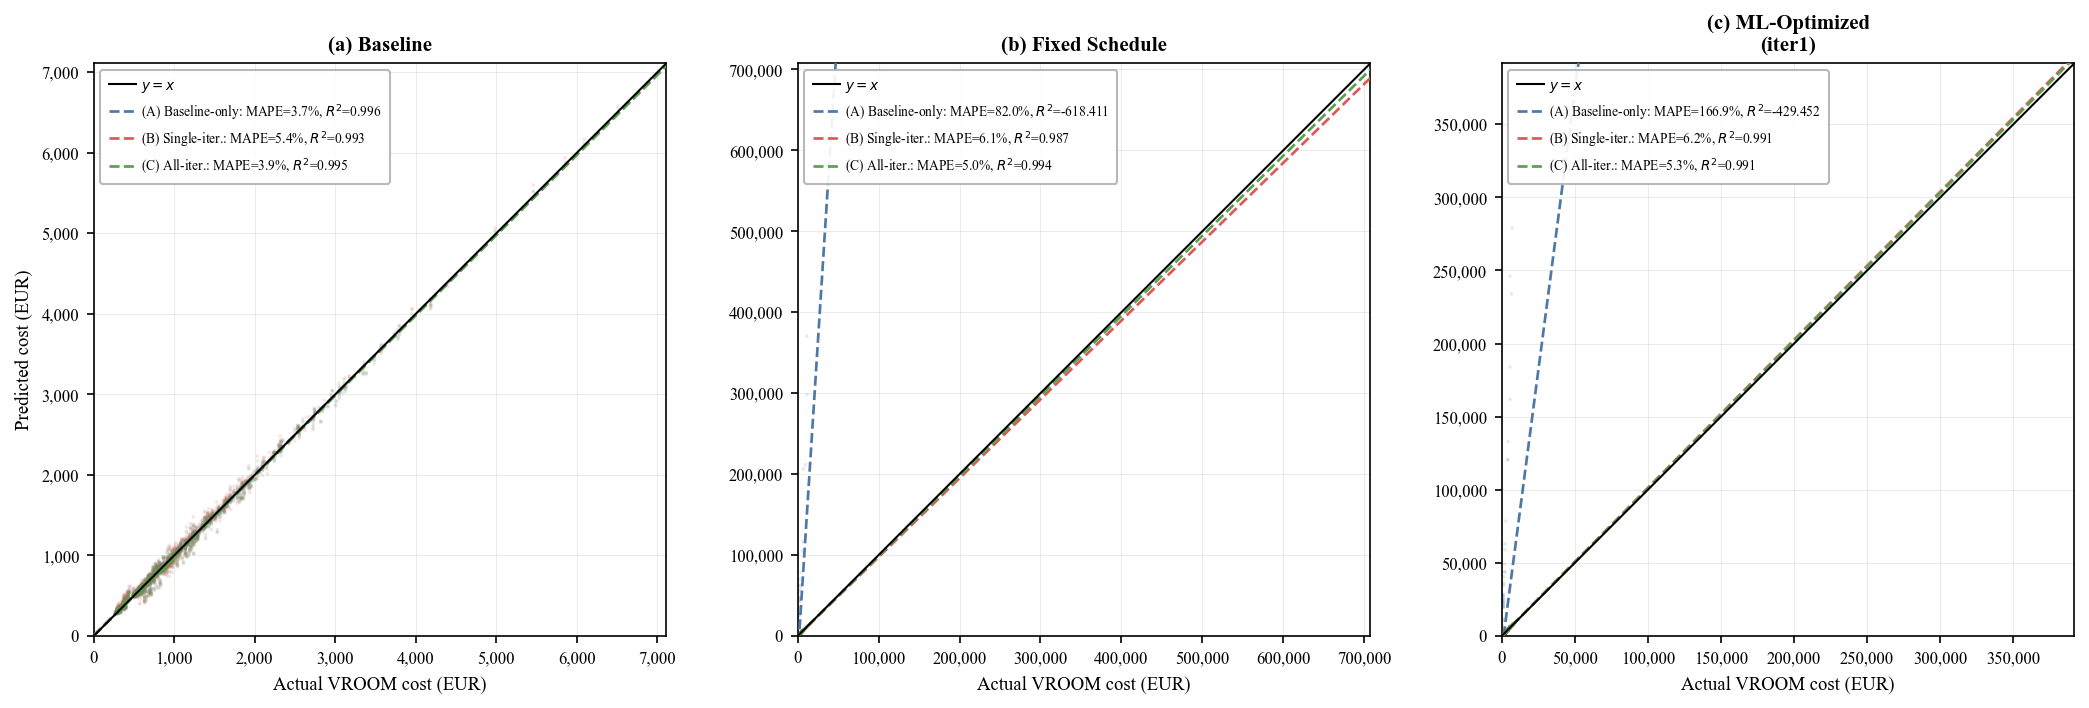

In [ ]:
# ═══════════════════════════════════════════════════════════════════════════
# §8.4a  Train 3 Models + Compute Predictions (run once)
# ═══════════════════════════════════════════════════════════════════════════

import matplotlib
import matplotlib.pyplot as plt
import matplotlib.ticker as mticker
from scipy import stats

SEEDS_FIG = [42, 123, 456, 789, 2024]

def _train_ensemble(X_tr, y_tr, seeds=SEEDS_FIG):
    pipes = []
    for seed in seeds:
        pipe = Pipeline([
            ("scaler", StandardScaler()),
            ("mlp", MLPRegressor(
                hidden_layer_sizes=ML_ARCH,
                activation="relu",
                alpha=ML_ALPHA,
                max_iter=2000,
                learning_rate="adaptive",
                early_stopping=True,
                validation_fraction=0.15,
                random_state=seed,
            )),
        ])
        pipe.fit(X_tr, y_tr)
        pipes.append(pipe)
    return pipes

def _predict_ensemble(pipes, X):
    return np.mean([p.predict(X) for p in pipes], axis=0)

def _mape(y_true, y_pred):
    return np.mean(np.abs((y_true - y_pred) / np.clip(y_true, 1, None))) * 100

def _r2(y_true, y_pred):
    ss_res = np.sum((y_true - y_pred) ** 2)
    ss_tot = np.sum((y_true - y_true.mean()) ** 2)
    return 1 - ss_res / ss_tot

print(_box("§8.4a — TRAIN MODELS + COMPUTE PREDICTIONS"))
print()

# ── 1. Select 3 evaluation scenarios ────────────────────────────────
print(_section(1, 3, "Preparing Evaluation Scenarios"))

df_eval_baseline = df_cv[df_cv["scenario"] == SC_BASELINE].copy()
print(_kv_line("(a) Baseline", f"{len(df_eval_baseline):,} rows"))

df_eval_fixed = df_cv[df_cv["scenario"] == SC_FIXED_EXPRESS].copy()
print(_kv_line("(b) Fixed+Express", f"{len(df_eval_fixed):,} rows"))

sa_ml_scenarios = [SC_SA_ML_EXPRESS, SC_SA_ML_BATCH]
df_sa_ml_all = df_cv[df_cv["scenario"].isin(sa_ml_scenarios)].copy()

iter_costs = (
    df_sa_ml_all.groupby("_iteration")["actual_cost"]
    .sum()
    .sort_values()
)
best_iter = iter_costs.index[0]
print(_kv_line("  Iteration costs (SA_ML)", ""))
for it, c in iter_costs.items():
    marker = " ◀ best" if it == best_iter else ""
    print(f"        {it:<12s}  {c:>12,.1f} EUR{marker}")

df_eval_ml = df_cv[
    (df_cv["_iteration"] == best_iter) &
    (df_cv["scenario"] == SC_SA_ML_EXPRESS)
].copy()
print(_kv_line(f"(c) ML-Opt ({best_iter})", f"{len(df_eval_ml):,} rows"))
print()

# ── 2. Train 3 models ───────────────────────────────────────────────
print(_section(2, 3, "Training 3 Models"))

df_train_a = df_cv[df_cv["scenario"] == SC_BASELINE].copy()
X_a = np.nan_to_num(df_train_a[ALL_COLS].values.astype(np.float64), nan=0.0, posinf=0.0, neginf=0.0)
y_a = df_train_a["actual_cost"].values

df_train_b = feature_parts[0].copy()
X_b = np.nan_to_num(df_train_b[ALL_COLS].values.astype(np.float64), nan=0.0, posinf=0.0, neginf=0.0)
y_b = df_train_b["actual_cost"].values

X_c = np.nan_to_num(df_cv[ALL_COLS].values.astype(np.float64), nan=0.0, posinf=0.0, neginf=0.0)
y_c = df_cv["actual_cost"].values

t0 = time.perf_counter()
pipes_a = _train_ensemble(X_a, y_a)
print(_kv_line("(A) Baseline-only", f"{len(y_a):,} train → {time.perf_counter()-t0:.0f}s"))

t0 = time.perf_counter()
pipes_b = _train_ensemble(X_b, y_b)
print(_kv_line("(B) Single-iteration", f"{len(y_b):,} train → {time.perf_counter()-t0:.0f}s"))

t0 = time.perf_counter()
pipes_c = _train_ensemble(X_c, y_c)
print(_kv_line("(C) All-iterations", f"{len(y_c):,} train → {time.perf_counter()-t0:.0f}s"))
print()

# ── 3. Compute predictions ──────────────────────────────────────────
print(_section(3, 3, "Computing Predictions"))

eval_sets = [
    ("(a) Baseline", df_eval_baseline),
    ("(b) Fixed Schedule", df_eval_fixed),
    (f"(c) ML-Opt ({best_iter})", df_eval_ml),
]
models = [
    ("Baseline-only", pipes_a, len(y_a)),
    ("Single-iteration", pipes_b, len(y_b)),
    ("All-iterations", pipes_c, len(y_c)),
]

# Store all predictions for the plot cell
predictions = {}  # {panel_label: {model_label: (y_true, y_pred)}}
metric_rows = []

for sc_label, df_sc in eval_sets:
    X_sc = np.nan_to_num(df_sc[ALL_COLS].values.astype(np.float64), nan=0.0, posinf=0.0, neginf=0.0)
    y_sc = df_sc["actual_cost"].values
    predictions[sc_label] = {}
    for m_label, pipes, n_tr in models:
        pred = _predict_ensemble(pipes, X_sc)
        predictions[sc_label][m_label] = (y_sc, pred)
        m = _mape(y_sc, pred)
        r = _r2(y_sc, pred)
        print(f"    {sc_label:<28s} × {m_label:<20s}  MAPE={m:5.1f}%  R²={r:.4f}")
        metric_rows.append({
            "Scenario": sc_label, "Model": m_label,
            "N_train": n_tr, "N_eval": len(y_sc),
            "MAPE (%)": round(m, 2), "R²": round(r, 4),
        })

df_metrics = pd.DataFrame(metric_rows)

display(df_metrics.style
    .format({"MAPE (%)": "{:.2f}", "R²": "{:.4f}",
             "N_train": "{:,}", "N_eval": "{:,}"})
    .set_caption("3 Scenarios × 3 Models — Prediction Accuracy")
    .set_table_styles([
        {"selector": "caption", "props": [
            ("font-size", "13px"), ("font-weight", "bold"), ("padding", "6px 0")]},
        {"selector": "th", "props": [
            ("background-color", "#FFCC00"), ("color", "#333"),
            ("padding", "5px 8px"), ("font-size", "11px"), ("text-align", "center")]},
        {"selector": "td", "props": [
            ("padding", "4px 8px"), ("font-size", "12px"), ("text-align", "right")]},
    ])
)

print("\nPredictions stored in `predictions` — run next cell to plot.")


Saved → figure_model_comparison.pdf + figure_model_comparison.png


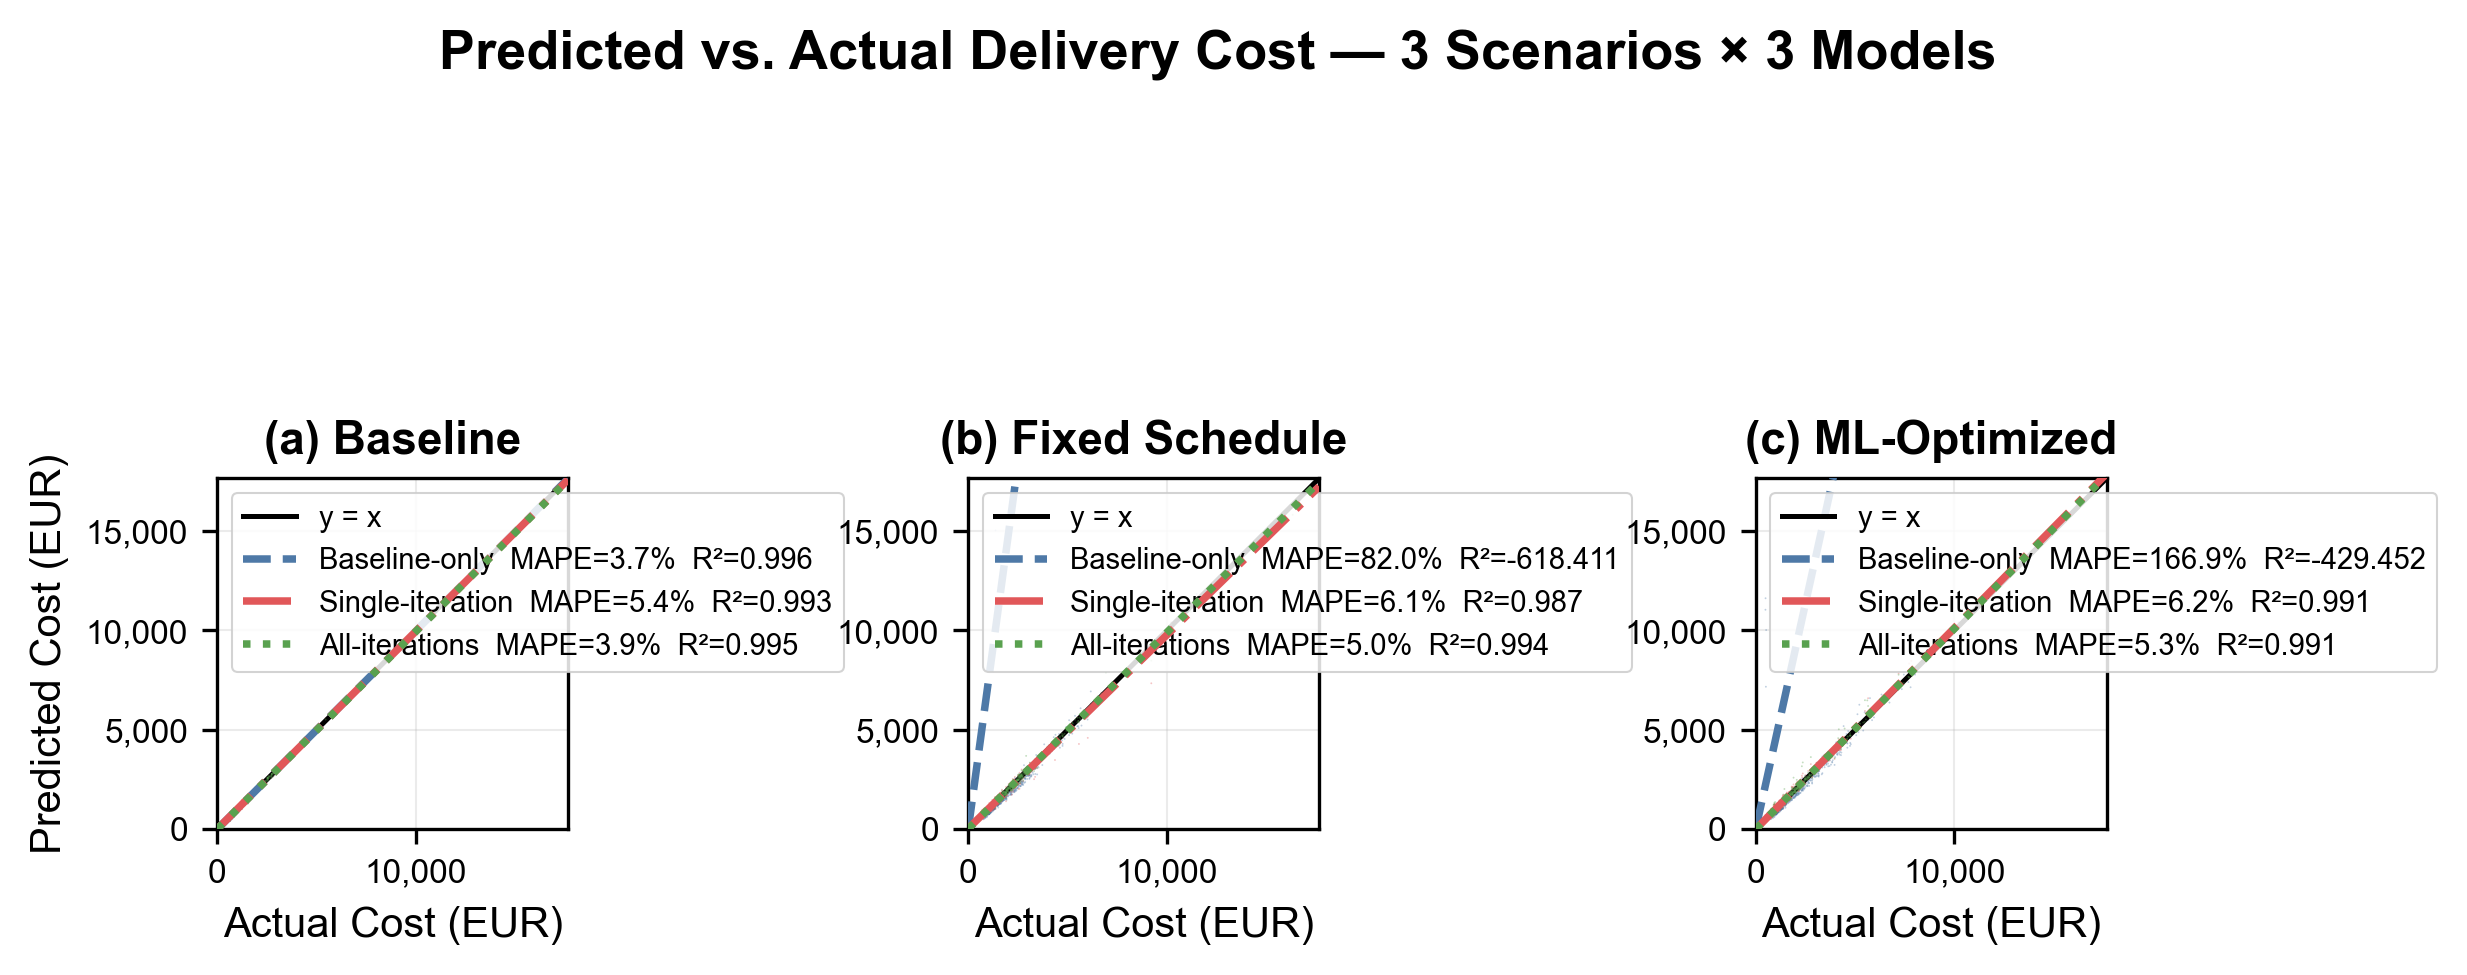

In [28]:
# ═══════════════════════════════════════════════════════════════════════════
# §8.4b  Paper Figure — 1×3 Panel (re-run this cell for plot changes)
# ═══════════════════════════════════════════════════════════════════════════
# Uses: predictions, eval_sets, models from the cell above

import matplotlib
import matplotlib.pyplot as plt
import matplotlib.ticker as mticker
from scipy import stats

matplotlib.rcParams.update({
    "font.family": "sans-serif",
    "font.sans-serif": ["Helvetica Neue", "Arial", "DejaVu Sans"],
    "font.size": 9,
    "axes.titlesize": 11,
    "axes.labelsize": 10,
    "xtick.labelsize": 8,
    "ytick.labelsize": 8,
    "legend.fontsize": 7.5,
    "figure.dpi": 300,
})

# ── Colours ──────────────────────────────────────────────────────────
MODEL_COLORS  = ["#4E79A7", "#E15759", "#59A14F"]
MODEL_LABELS  = ["Baseline-only", "Single-iteration", "All-iterations"]
MODEL_LSTYLES = ["--", "-.", ":"]
MODEL_MARKERS = ["o", "s", "D"]

SCATTER_ALPHA = 0.35
SCATTER_SIZE  = 0.8      # kleine Punkte

PANEL_LABELS = ["(a)", "(b)", "(c)"]
PANEL_TITLES = ["Baseline", "Fixed Schedule", "ML-Optimized"]

# ── Figure ───────────────────────────────────────────────────────────
fig, axes = plt.subplots(1, 3, figsize=(8, 4), constrained_layout=True)

# Axis limits nur aus den "guten" Modellen (B + C), nicht aus dem
# kaputten Baseline-only in (b)/(c) — sonst wird alles zusammengequetscht
good_vals = []
for sc_label, _ in eval_sets:
    for mi, (m_label, _, _) in enumerate(models):
        yt, yp = predictions[sc_label][m_label]
        good_vals.extend(yt)
        if mi > 0:          # skip Baseline-only model predictions
            good_vals.extend(yp)
        else:
            # Baseline-only: nur in Panel (a) brauchbar
            if "(a)" in sc_label:
                good_vals.extend(yp)
max_val = max(good_vals) * 1.08

for panel_i, (sc_label, _) in enumerate(eval_sets):
    ax = axes[panel_i]

    # Identity line y = x — solid black
    ax.plot([0, max_val], [0, max_val], color="black", ls="-", lw=1.2,
            zorder=4, label="y = x")

    # Per model: scatter + dashed regression line
    for mi, (m_label, _, _) in enumerate(models):
        yt, yp = predictions[sc_label][m_label]
        col = MODEL_COLORS[mi]

        # Scatter — PLZ-level data points (tiny dots)
        ax.scatter(yt, yp,
                   s=SCATTER_SIZE, alpha=SCATTER_ALPHA,
                   color=col, marker=".",
                   edgecolors="none", linewidths=0,
                   zorder=2 + mi)

        # Regression line — dashed (baseline forced through origin)
        m = _mape(yt, yp)
        r = _r2(yt, yp)
        x_line = np.linspace(0, max_val, 200)
        if mi == 0:  # Baseline-only: force through origin
            slope = np.sum(yt * yp) / np.sum(yt ** 2)
            intercept = 0.0
        else:
            slope, intercept, *_ = stats.linregress(yt, yp)
        lbl = f"{MODEL_LABELS[mi]}  MAPE={m:.1f}%  R²={r:.3f}"
        ax.plot(x_line, slope * x_line + intercept,
                color=col, ls=MODEL_LSTYLES[mi],
                lw=1.8, zorder=5 + mi, label=lbl)

    ax.set_xlim(0, max_val)
    ax.set_ylim(0, max_val)
    ax.set_aspect("equal")
    ax.xaxis.set_major_formatter(mticker.StrMethodFormatter("{x:,.0f}"))
    ax.yaxis.set_major_formatter(mticker.StrMethodFormatter("{x:,.0f}"))
    ax.set_xlabel("Actual Cost (EUR)")
    ax.set_ylabel("Predicted Cost (EUR)" if panel_i == 0 else "")
    ax.set_title(f"{PANEL_LABELS[panel_i]} {PANEL_TITLES[panel_i]}", weight="bold")

    leg = ax.legend(loc="upper left", frameon=True, framealpha=0.85,
                    edgecolor="#ccc", fontsize=7, handlelength=1.8)
    leg.get_frame().set_linewidth(0.5)

fig.suptitle("Predicted vs. Actual Delivery Cost — 3 Scenarios × 3 Models",
             fontsize=13, weight="bold", y=1.02)

out_pdf = RESULTS_DIR / "figure_model_comparison.pdf"
out_png = RESULTS_DIR / "figure_model_comparison.png"

fig.savefig(out_pdf, bbox_inches="tight", dpi=300)
fig.savefig(out_png, bbox_inches="tight", dpi=300)
print(f"\nSaved → {out_pdf.name} + {out_png.name}")
plt.show()

## §8.5  Final Optimization — Multi-Start CD with Fully Trained ML

Run an **enhanced Coordinate Descent** with multi-start (20 random restarts ×
100 rounds, shuffled PLZ order) using the fully trained ML ensemble from §8.4.
Routes both Express and Batch-Only scenarios via VROOM, then compares all
iteration runs to select the overall best solution for §9 KPI analysis.

**Key improvements over refinement-loop CD:**
- 20 independent restarts (1× fixed init + 19× random) → escapes local optima
- 100 rounds per restart (vs 10) → deeper convergence
- Shuffled PLZ order each round → eliminates sequential bias
- Fleet balancing post-processing retained for both scenarios

In [20]:
# ═══════════════════════════════════════════════════════════════════════════
# §8.5  Final Multi-Start CD + VROOM Routing + Best Run Selection
# ═══════════════════════════════════════════════════════════════════════════

import importlib, time, pickle, logging as _logging, os as _os, sys as _sys, io as _io

# ── Restore stderr in case previous run crashed mid-redirect ─────────
_sys.stderr = _sys.__stderr__

importlib.reload(importlib.import_module("lmd.features"))
importlib.reload(importlib.import_module("lmd.ml_cost"))
importlib.reload(importlib.import_module("lmd.optimization"))

from lmd.features import build_feature_matrix, ALL_COLS
from lmd.ml_cost import MLCostPredictor
from lmd.optimization import (
    build_cost_matrices_ml, optimize_cd_ml, balance_fleet_per_hub_ml,
    build_fixed_schedules,
)
from lmd.config import provider_to_demand_prefix

# ── Load wsf and baseline_job_caps from checkpoint if missing ────────
_need_wsf = "wsf" not in dir() or not isinstance(wsf, float)
_need_caps = "baseline_job_caps" not in dir() or not isinstance(baseline_job_caps, dict)
if _need_wsf or _need_caps:
    _bl_pkl = RESULTS_DIR / "checkpoints" / "02_baseline.pkl"
    if _bl_pkl.exists():
        _ck_bl = pickle.loads(_bl_pkl.read_bytes())
        if _need_wsf:
            wsf = _ck_bl.get("wsf", 1.0)
        if _need_caps:
            baseline_job_caps = _ck_bl["baseline_job_caps"]
        print(f"  [checkpoint] Loaded wsf={wsf:.3f} + baseline_job_caps from 02_baseline.pkl")
        del _ck_bl
    else:
        raise RuntimeError("Cannot find 02_baseline.pkl — run §2 (baseline routing) first")

# ── Suppress verbose library output ─────────────────────────────────
_logging.disable(_logging.INFO)
for _h in _logging.root.handlers:
    _h.setLevel(_logging.WARNING)
for _n in list(_logging.Logger.manager.loggerDict):
    _logging.getLogger(_n).setLevel(_logging.WARNING)
_os.environ["TQDM_DISABLE"] = "1"
try:
    import tqdm as _tqdm_mod
    _tqdm_mod.tqdm.disable = True
except ImportError:
    pass
_real_stderr = _sys.stderr
_sys.stderr = _io.StringIO()

# ── Config ───────────────────────────────────────────────────────────
FINAL_N_RESTARTS = 20
FINAL_MAX_ROUNDS = 100
FINAL_SHUFFLE = True
FINAL_SEED = 2026

ML_ALPHA = 0.001
ML_ARCH = (512, 512, 256, 128)

def _box(title, width=78):
    pad = width - 4 - len(title)
    left = pad // 2
    right = pad - left
    return "\n".join([
        f"╔{'═' * (width - 2)}╗",
        f"║{' ' * left}  {title}{' ' * right}║",
        f"╚{'═' * (width - 2)}╝",
    ])

def _section(number, total, label, width=78):
    tag = f" [{number}/{total}] {label} "
    remaining = width - len(tag)
    left = 4
    right = remaining - left
    return f"{'─' * left}{tag}{'─' * max(right, 2)}"

def _kv_line(key, value, indent=4):
    dots = "." * max(1, 44 - indent - len(key))
    return f"{' ' * indent}{key} {dots} {value}"

def _progress_bar(current, total, width=30):
    filled = int(width * current / total) if total > 0 else 0
    bar = "█" * filled + "░" * (width - filled)
    return f"[{bar}] {current}/{total}"

try:
    t_total = time.perf_counter()

    print(_box("§8.5  FINAL MULTI-START CD OPTIMIZATION"))
    print(f"  Config: {FINAL_N_RESTARTS} restarts × {FINAL_MAX_ROUNDS} rounds, "
          f"shuffle={'ON' if FINAL_SHUFFLE else 'OFF'}, seed={FINAL_SEED}")
    print(f"  Started: {time.strftime('%H:%M:%S')}")
    print()

    # ── Try loading existing checkpoint to skip Phases 1-4 ───────────
    _final_pkl = RESULTS_DIR / "checkpoints" / "10_final_optimization.pkl"
    if _final_pkl.exists():
        _ck_final = pickle.loads(_final_pkl.read_bytes())
        final_schedules = _ck_final["final_schedules"]
        final_routes = _ck_final["final_routes"]
        final_solutions = _ck_final["final_solutions"]
        final_optim_data = _ck_final["final_optim_data"]
        del _ck_final
        dt_optim = 0.0
        print("  ✓ Loaded checkpoint 10_final_optimization — skipping Phases 1–4")
        print()
    else:
        # ═════════════════════════════════════════════════════════════════
        # 1. Reconstruct ml_prep
        # ═════════════════════════════════════════════════════════════════
        print(_section(1, 5, "Reconstructing ml_prep"))

        ml_prep = {}
        for provider in PROVIDERS:
            pdata = provider_data[provider]
            odata = optimization_data[provider]

            hub_coords_by_plz = {}
            for _, hr in pdata["df_assignments"].iterrows():
                hub_coords_by_plz[hr["plz"]] = (hr["hub_lon"], hr["hub_lat"])

            prefix = provider_to_demand_prefix(provider)
            col_total = f"{prefix}_total"
            daily_wgs = pdata["daily_gdfs_wgs"]
            plz_day_coords: dict = {}

            for plz_code in odata["plz_keys"]:
                plz_day_coords[plz_code] = {}
                for d in range(N_DAYS):
                    gdf_d = daily_wgs.get(d)
                    if gdf_d is None:
                        continue
                    pts = gdf_d[gdf_d["plz"] == plz_code]
                    if len(pts) == 0:
                        continue
                    lons = pts["lon"].values.astype(np.float64)
                    lats = pts["lat"].values.astype(np.float64)
                    psd = (
                        pts[col_total].values.astype(np.float64)
                        if col_total in pts.columns
                        else np.ones(len(pts))
                    )
                    plz_day_coords[plz_code][d] = (lons, lats, psd)

            ml_prep[provider] = {
                "plz_day_coords": plz_day_coords,
                "hub_coords_by_plz": hub_coords_by_plz,
            }
            print(_kv_line(f"{provider}", f"{len(plz_day_coords)} PLZ, "
                           f"{len(hub_coords_by_plz)} hub assignments"))
        print()

        # ═════════════════════════════════════════════════════════════════
        # 2. Retrain ML ensemble on ALL accumulated data (df_cv)
        # ═════════════════════════════════════════════════════════════════
        print(_section(2, 5, "Training Final ML Ensemble"))

        X_final = df_cv[ALL_COLS].copy()
        y_final = df_cv["actual_cost"].values

        ml_final = MLCostPredictor.train(
            X_final, y_final, alpha=ML_ALPHA, arch=ML_ARCH,
        )
        pred_final = ml_final.predict(X_final)
        mape_final = np.mean(np.abs((y_final - pred_final) / np.clip(y_final, 1, None))) * 100
        r2_final = 1 - np.sum((y_final - pred_final) ** 2) / np.sum((y_final - y_final.mean()) ** 2)

        print(_kv_line("Training samples", f"{len(df_cv):,}"))
        print(_kv_line("In-sample MAPE", f"{mape_final:.2f}%"))
        print(_kv_line("In-sample R²", f"{r2_final:.4f}"))
        print()

        # ═════════════════════════════════════════════════════════════════
        # 3. Multi-Start CD for all providers (Express + Batch)
        # ═════════════════════════════════════════════════════════════════
        print(_section(3, 5, f"Multi-Start CD ({FINAL_N_RESTARTS}× restarts)"))

        final_schedules = {}
        final_optim_data = {}

        print()
        print(f"    {'Provider':<12s} {'PLZ':>5s}  {'Express (EUR)':>14s} "
              f"{'Best/Worst Restart':>20s}  {'Batch (EUR)':>14s}  {'Time':>8s}")
        print(f"    {'─' * 12} {'─' * 5}  {'─' * 14} {'─' * 20}  {'─' * 14}  {'─' * 8}")

        for pi, provider in enumerate(PROVIDERS):
            t_prov = time.perf_counter()
            odata = optimization_data[provider]
            prep = ml_prep[provider]
            plz_keys = odata["plz_keys"]
            schedules = odata["schedules"]

            _fixed_scheds = build_fixed_schedules(plz_keys, carrier=provider)
            _sched_to_idx = {s: si for si, s in enumerate(schedules)}
            _fixed_asn = np.array([
                _sched_to_idx.get(
                    frozenset(_fixed_scheds.get(pk, set(range(N_DAYS)))), 0
                )
                for pk in plz_keys
            ], dtype=np.intp)

            mx_expr = build_cost_matrices_ml(
                plz_keys, odata["plz_data"], schedules, ml_final,
                provider, prep["plz_day_coords"], prep["hub_coords_by_plz"],
                fast_share_b2c=FAST_SHARE_B2C, fast_share_b2b=FAST_SHARE_B2B,
            )
            mx_batch = build_cost_matrices_ml(
                plz_keys, odata["plz_data"], schedules, ml_final,
                provider, prep["plz_day_coords"], prep["hub_coords_by_plz"],
                fast_share_b2c=0.0, fast_share_b2b=0.0,
            )

            sa_e = optimize_cd_ml(
                plz_keys, odata["plz_hub_arr"], odata["hub_plz_list"],
                mx_expr, schedules, batch_only=False,
                fixed_assignment=_fixed_asn,
                n_restarts=FINAL_N_RESTARTS,
                max_rounds=FINAL_MAX_ROUNDS,
                shuffle_plz=FINAL_SHUFFLE,
                seed=FINAL_SEED + pi,
            )
            bal_e = balance_fleet_per_hub_ml(
                sa_e, plz_keys, odata["plz_hub_arr"],
                odata["hub_plz_list"], mx_expr, schedules,
            )

            sa_b = optimize_cd_ml(
                plz_keys, odata["plz_hub_arr"], odata["hub_plz_list"],
                mx_batch, schedules, batch_only=True,
                fixed_assignment=_fixed_asn,
            )
            bal_b = balance_fleet_per_hub_ml(
                sa_b, plz_keys, odata["plz_hub_arr"],
                odata["hub_plz_list"], mx_batch, schedules,
            )

            final_schedules[provider] = {
                SC_SA_ML_EXPRESS: bal_e["schedules_per_plz"],
                SC_SA_ML_BATCH: bal_b["schedules_per_plz"],
            }
            final_optim_data[provider] = {
                "sa_ml_expr": sa_e, "bal_ml_expr": bal_e,
                "sa_ml_batch": sa_b, "bal_ml_batch": bal_b,
                "matrices_ml_expr": mx_expr, "matrices_ml_batch": mx_batch,
            }

            rc = sa_e["restart_costs"]
            dt = time.perf_counter() - t_prov
            print(f"    {provider:<12s} {len(plz_keys):>5d}  {bal_e['cost']:>13,.0f}  "
                  f"{min(rc):>9,.0f} / {max(rc):>9,.0f}  "
                  f"{bal_b['cost']:>13,.0f}  {dt:>7.1f}s")

        dt_optim = time.perf_counter() - t_total
        print(f"\n{_kv_line('Total optimisation time', f'{dt_optim / 60:.1f} min')}")
        print()

        # ═════════════════════════════════════════════════════════════════
        # 4. VROOM Routing for final schedules
        # ═════════════════════════════════════════════════════════════════
        print(_section(4, 5, "VROOM Routing (Final Schedules)"))

        total_route_tasks = len(PROVIDERS) * 2
        route_task_idx = 0

        final_routes = {}
        final_solutions = {}

        for sc_name in [SC_SA_ML_EXPRESS, SC_SA_ML_BATCH]:
            sc_route_parts = []
            sc_solutions = {}
            is_batch = sc_name == SC_SA_ML_BATCH

            for provider in PROVIDERS:
                route_task_idx += 1
                pdata = provider_data[provider]
                sc_sched = final_schedules[provider][sc_name]
                sc_fast = pdata["fast_share"] if not is_batch else 0.0
                cache_tag = f"{provider.lower()}_final_{'batch' if is_batch else 'expr'}"

                print(f"    {_progress_bar(route_task_idx, total_route_tasks)}  "
                      f"{'Batch' if is_batch else 'Express'} / {provider}", flush=True)

                sc_requests, _ = routing.build_scenario_requests(
                    sc_sched, pdata["df_assignments"], pdata["daily_gdfs_wgs"],
                    fast_share=sc_fast,
                    scenario_name=f"{sc_name} {provider} final",
                    speed_factor=wsf,
                    max_jobs_per_plz=baseline_job_caps.get(provider, {}),
                )

                result_dir = (RESULTS_DIR
                              / sc_name.lower().replace(' ', '_').replace('+', 'plus')
                              / provider.lower())
                sc_sol, _ = routing.solve_scenario(
                    sc_requests, f"{sc_name} {provider}",
                    cache_tag=cache_tag, save_intermediate=result_dir,
                )

                routes_df = routing.parse_routes(
                    sc_sol, sc_name, pdata["df_assignments"],
                    provider_name=provider,
                )
                sc_route_parts.append(routes_df)
                sc_solutions[provider] = sc_sol

            final_routes[sc_name] = pd.concat(sc_route_parts, ignore_index=True)
            final_solutions[sc_name] = sc_solutions

        save_checkpoint(
            "10_final_optimization",
            final_schedules=final_schedules,
            final_routes=final_routes,
            final_solutions=final_solutions,
            final_optim_data=final_optim_data,
        )

        dt_route = time.perf_counter() - t_total - dt_optim
        print(f"\n{_kv_line('Routing time', f'{dt_route / 60:.1f} min')}")
        print(f"{_kv_line('Checkpoint', 'saved (10_final_optimization)')}")
        print()

    # ═══════════════════════════════════════════════════════════════════════
    # 5. Compare ALL runs → select best → update all_routes
    # ═══════════════════════════════════════════════════════════════════════
    print(_section(5, 5, "Best Run Selection"))

    comparison_rows = []

    for label, routes_dict, _ in all_snapshots:
        for sc_name in [SC_SA_ML_EXPRESS, SC_SA_ML_BATCH]:
            if sc_name in routes_dict:
                df_r = routes_dict[sc_name]
                cost = float(df_r["cost"].sum()) / 100 if "cost" in df_r.columns else float("nan")
                n_routes = len(df_r)
                km = float(df_r["distance_km"].sum()) if "distance_km" in df_r.columns else float("nan")
                comparison_rows.append({
                    "Run": label,
                    "Scenario": sc_name,
                    "VROOM Cost (EUR)": cost,
                    "Routes": n_routes,
                    "Total km": km,
                })

    for sc_name in [SC_SA_ML_EXPRESS, SC_SA_ML_BATCH]:
        df_r = final_routes[sc_name]
        cost = float(df_r["cost"].sum()) / 100 if "cost" in df_r.columns else float("nan")
        n_routes = len(df_r)
        km = float(df_r["distance_km"].sum()) if "distance_km" in df_r.columns else float("nan")
        comparison_rows.append({
            "Run": "FINAL (§8.5)",
            "Scenario": sc_name,
            "VROOM Cost (EUR)": cost,
            "Routes": n_routes,
            "Total km": km,
        })

    df_comparison = pd.DataFrame(comparison_rows)

    best_runs = {}
    for sc_name in [SC_SA_ML_EXPRESS, SC_SA_ML_BATCH]:
        sc_rows = df_comparison[df_comparison["Scenario"] == sc_name].copy()
        if len(sc_rows) == 0:
            continue
        best_idx = sc_rows["VROOM Cost (EUR)"].idxmin()
        best_run = sc_rows.loc[best_idx, "Run"]
        best_cost = sc_rows.loc[best_idx, "VROOM Cost (EUR)"]
        best_runs[sc_name] = best_run

        print(f"  {sc_name}:")
        print(f"    Best run: {best_run}  (€{best_cost:,.0f})")

        if best_run == "FINAL (§8.5)":
            all_routes[sc_name] = final_routes[sc_name]
            for prov in PROVIDERS:
                scenario_schedules_by_provider[prov][sc_name] = \
                    final_schedules[prov][sc_name]
        else:
            for lbl, routes_dict, sched_snap in all_snapshots:
                if lbl == best_run and sc_name in routes_dict:
                    all_routes[sc_name] = routes_dict[sc_name]
                    for prov in PROVIDERS:
                        prov_sched = sched_snap.get(prov, {})
                        if sc_name in prov_sched:
                            scenario_schedules_by_provider[prov][sc_name] = \
                                prov_sched[sc_name]
                    break

    print()

    for sc_name in [SC_SA_ML_EXPRESS, SC_SA_ML_BATCH]:
        sc_df = df_comparison[df_comparison["Scenario"] == sc_name].copy()
        if len(sc_df) == 0:
            continue
        best_label = best_runs.get(sc_name, "")
        sc_df["Best?"] = sc_df["Run"].apply(lambda x: "★" if x == best_label else "")

        display(
            sc_df.style
            .format({
                "VROOM Cost (EUR)": "€{:,.0f}",
                "Routes": "{:,}",
                "Total km": "{:,.0f}",
            })
            .set_caption(f"Run Comparison — {sc_name}")
            .apply(lambda row: [
                "background-color: #d4edda; font-weight: bold"
                if row["Run"] == best_label else ""
            ] * len(row), axis=1)
            .set_table_styles([
                {"selector": "caption", "props": [
                    ("font-size", "14px"), ("font-weight", "bold"),
                    ("text-align", "left"), ("padding", "8px 0"),
                ]},
                {"selector": "th", "props": [
                    ("background-color", "#FFCC00"), ("color", "#333"),
                    ("padding", "6px 10px"), ("font-size", "11px"),
                ]},
            ])
            .hide(axis="index")
        )

    dt_total_final = time.perf_counter() - t_total
    print()
    w = 63
    print(f"  ╔{'═' * w}╗")
    print(f"  ║  FINAL OPTIMIZATION COMPLETE{' ' * (w - 29)}║")
    print(f"  ╠{'═' * w}╣")
    for sc_name in [SC_SA_ML_EXPRESS, SC_SA_ML_BATCH]:
        best = best_runs.get(sc_name, "?")
        df_best = all_routes[sc_name]
        cost_val = f"€{df_best['cost'].sum() / 100:,.0f}" if "cost" in df_best.columns else "n/a"
        line = f"  ║  {sc_name}: {best} ({cost_val})"
        print(f"{line}{' ' * (w + 3 - len(line))}║")
    print(f"  ║  Total runtime: {dt_total_final / 60:.1f} min{' ' * (w - 26 - len(f'{dt_total_final / 60:.1f}'))}║")
    print(f"  ╚{'═' * w}╝")
    print()
    print("→ Re-run §9 KPI cells to see updated results.")

finally:
    _sys.stderr = _real_stderr
    _os.environ.pop("TQDM_DISABLE", None)
    try:
        _tqdm_mod.tqdm.disable = False
    except Exception:
        pass
    _logging.disable(_logging.NOTSET)
    for _n in list(_logging.Logger.manager.loggerDict):
        _logging.getLogger(_n).setLevel(_logging.NOTSET)
    log.setLevel(_logging.INFO)

╔════════════════════════════════════════════════════════════════════════════╗
║                   §8.5  FINAL MULTI-START CD OPTIMIZATION                  ║
╚════════════════════════════════════════════════════════════════════════════╝
  Config: 20 restarts × 100 rounds, shuffle=ON, seed=2026
  Started: 02:03:44

  ✓ Loaded checkpoint 10_final_optimization — skipping Phases 1–4

──── [5/5] Best Run Selection ────────────────────────────────────────────────
  SA_ML + Express:
    Best run: iter1  (€1,537,336)
  SA_ML Batch-Only:
    Best run: iter1  (€1,478,123)



Run,Scenario,VROOM Cost (EUR),Routes,Total km,Best?
iter1,SA_ML + Express,"€1,537,336","5,820","243,232",★
iter2,SA_ML + Express,"€1,537,336","5,820","243,232",
iter3,SA_ML + Express,"€1,589,328","5,976","255,124",
iter4,SA_ML + Express,"€1,585,222","5,964","254,552",
iter5,SA_ML + Express,"€1,585,456","5,966","254,476",
iter6,SA_ML + Express,"€1,584,771","5,967","254,395",
iter7,SA_ML + Express,"€1,587,967","5,968","255,395",
current,SA_ML + Express,"€1,586,774","5,968","254,853",
FINAL (§8.5),SA_ML + Express,"€1,585,461","5,962","255,151",


Run,Scenario,VROOM Cost (EUR),Routes,Total km,Best?
iter1,SA_ML Batch-Only,"€1,478,123","5,793","222,914",★
iter2,SA_ML Batch-Only,"€1,478,123","5,793","222,914",
iter3,SA_ML Batch-Only,"€1,480,006","5,805","222,941",
iter4,SA_ML Batch-Only,"€1,482,476","5,814","223,082",
iter5,SA_ML Batch-Only,"€1,479,588","5,802","222,849",
iter6,SA_ML Batch-Only,"€1,478,323","5,798","222,593",
iter7,SA_ML Batch-Only,"€1,481,766","5,810","223,181",
current,SA_ML Batch-Only,"€1,481,236","5,806","223,312",
FINAL (§8.5),SA_ML Batch-Only,"€1,478,404","5,798","222,594",



  ╔═══════════════════════════════════════════════════════════════╗
  ║  FINAL OPTIMIZATION COMPLETE                                  ║
  ╠═══════════════════════════════════════════════════════════════╣
  ║  SA_ML + Express: iter1 (€1,537,336)                          ║
  ║  SA_ML Batch-Only: iter1 (€1,478,123)                         ║
  ║  Total runtime: 0.0 min                                  ║
  ╚═══════════════════════════════════════════════════════════════╝

→ Re-run §9 KPI cells to see updated results.


### 8.1 Updated KPIs — All 5 Scenarios

With all SA_ML routes in place, recompute the full KPI table spanning
all five scenarios.  The comparison table shows the ML-SA results
per provider.

In [21]:
# ═══════════════════════════════════════════════════════════════════════════
# §9  KPI-Vergleich: alle 5 Szenarien
# ═══════════════════════════════════════════════════════════════════════════

KPI_SCENARIOS = [SC_BASELINE, SC_FIXED_EXPRESS, SC_FIXED_BATCH,
                 SC_SA_ML_EXPRESS, SC_SA_ML_BATCH]
KPI_LABELS    = {
    SC_BASELINE:      "Baseline",
    SC_FIXED_EXPRESS:  "Fixed+Express",
    SC_FIXED_BATCH:    "Fixed Batch-Only",
    SC_SA_ML_EXPRESS:  "ML-Opt+Express",
    SC_SA_ML_BATCH:    "ML-Opt Batch-Only",
}

# ── 1. Aggregate KPIs per scenario ────────────────────────────────────
agg_rows = []
for sc in KPI_SCENARIOS:
    df_r = all_routes[sc]
    n_routes   = len(df_r)
    tot_parc   = int(df_r["parcels"].sum())
    tot_km     = df_r["distance_km"].sum()
    tot_cost   = df_r["cost"].sum() / 100
    avg_km     = df_r["distance_km"].mean()
    avg_parc   = df_r["parcels"].mean()
    avg_load   = df_r["load_factor"].mean() * 100
    avg_stops  = df_r["n_stops"].mean()
    avg_cost   = df_r["cost"].mean() / 100
    avg_travel = df_r["travel_h"].mean()
    avg_total  = df_r["total_h"].mean()

    agg_rows.append({
        "Scenario":             KPI_LABELS[sc],
        "Routes (= Vehicles)":  n_routes,
        "Total Parcels":        tot_parc,
        "Total km":             round(tot_km, 0),
        "Total Cost (EUR)":     round(tot_cost, 0),
        "Avg km / Vehicle":     round(avg_km, 1),
        "Avg Parcels / Vehicle": round(avg_parc, 1),
        "Avg Stops / Vehicle":  round(avg_stops, 1),
        "Avg Load Factor (%)":  round(avg_load, 1),
        "Avg Cost / Vehicle (EUR)": round(avg_cost, 0),
        "Avg Travel h / Vehicle": round(avg_travel, 2),
        "Avg Total h / Vehicle": round(avg_total, 2),
    })

df_agg = pd.DataFrame(agg_rows).set_index("Scenario")

# Δ vs Baseline
bl = df_agg.loc["Baseline"]
delta_rows = []
for sc in KPI_LABELS.values():
    row = df_agg.loc[sc]
    d = {"Scenario": sc}
    for col in df_agg.columns:
        if bl[col] != 0:
            d[col] = f"{(row[col] / bl[col] - 1) * 100:+.1f}%"
        else:
            d[col] = "–"
    delta_rows.append(d)
df_delta = pd.DataFrame(delta_rows).set_index("Scenario")

print(_box("§9 — KPI-Vergleich (alle 5 Szenarien, aggregiert)"))
print()
display(df_agg.T.style
    .format(lambda x: f"{x:,.1f}" if isinstance(x, float) else f"{x:,}" if isinstance(x, int) else x)
    .set_caption("KPIs — alle 5 Szenarien (aggregiert)")
    .set_table_styles([
        {"selector": "caption", "props": [
            ("font-size", "13px"), ("font-weight", "bold"), ("padding", "6px 0")]},
        {"selector": "th", "props": [
            ("background-color", "#FFCC00"), ("color", "#333"),
            ("padding", "5px 8px"), ("font-size", "11px")]},
        {"selector": "td", "props": [
            ("padding", "4px 8px"), ("font-size", "12px"), ("text-align", "right")]},
    ])
)

print("\nΔ vs Baseline:")
display(df_delta.T.style
    .set_caption("Veränderung gegenüber Baseline (%)")
    .set_table_styles([
        {"selector": "caption", "props": [
            ("font-size", "12px"), ("font-weight", "bold"), ("padding", "6px 0")]},
        {"selector": "th", "props": [
            ("background-color", "#E8E8E8"), ("padding", "4px 8px"), ("font-size", "11px")]},
        {"selector": "td", "props": [
            ("padding", "4px 8px"), ("font-size", "12px"), ("text-align", "right")]},
    ])
)

# ── 2. KPIs per scenario × LSP ──────────────────────────────────────
print("\n")
print(_box("§9 — KPI-Vergleich pro LSP"))
print()

lsp_rows = []
for sc in KPI_SCENARIOS:
    df_r = all_routes[sc]
    for prov in PROVIDERS:
        dfp = df_r[df_r["provider"] == prov]
        if len(dfp) == 0:
            continue
        lsp_rows.append({
            "Scenario":             KPI_LABELS[sc],
            "LSP":                  prov,
            "Routes":               len(dfp),
            "Parcels":              int(dfp["parcels"].sum()),
            "Total km":             round(dfp["distance_km"].sum(), 0),
            "Total Cost (EUR)":     round(dfp["cost"].sum() / 100, 0),
            "Avg km / Vehicle":     round(dfp["distance_km"].mean(), 1),
            "Avg Parcels / Vehicle": round(dfp["parcels"].mean(), 1),
            "Avg Load (%)":         round(dfp["load_factor"].mean() * 100, 1),
            "Avg Cost / Vehicle":   round(dfp["cost"].mean() / 100, 0),
        })

df_lsp = pd.DataFrame(lsp_rows)

kpi_cols = ["Routes", "Parcels", "Total km", "Total Cost (EUR)",
            "Avg km / Vehicle", "Avg Parcels / Vehicle",
            "Avg Load (%)", "Avg Cost / Vehicle"]

df_pivot = df_lsp.pivot_table(
    index="LSP", columns="Scenario", values=kpi_cols, aggfunc="first",
)
df_pivot = df_pivot.reorder_levels([1, 0], axis=1).sort_index(axis=1)
df_pivot = df_pivot[
    [(KPI_LABELS[s], kpi) for s in KPI_SCENARIOS for kpi in kpi_cols]
]

display(df_pivot.style
    .format(lambda x: f"{x:,.1f}" if isinstance(x, float) else
                      f"{x:,}" if isinstance(x, (int, np.integer)) else
                      str(x) if pd.notna(x) else "–")
    .set_caption("KPIs pro LSP — alle 5 Szenarien")
    .set_table_styles([
        {"selector": "caption", "props": [
            ("font-size", "13px"), ("font-weight", "bold"), ("padding", "6px 0")]},
        {"selector": "th", "props": [
            ("background-color", "#FFCC00"), ("color", "#333"),
            ("padding", "4px 6px"), ("font-size", "10px"), ("text-align", "center")]},
        {"selector": "td", "props": [
            ("padding", "3px 6px"), ("font-size", "11px"), ("text-align", "right")]},
    ])
)

╔════════════════════════════════════════════════════════════════════════════╗
║              §9 — KPI-Vergleich (alle 5 Szenarien, aggregiert)             ║
╚════════════════════════════════════════════════════════════════════════════╝



Scenario,Baseline,Fixed+Express,Fixed Batch-Only,ML-Opt+Express,ML-Opt Batch-Only
Routes (= Vehicles),"6,180.0","5,999.0","5,885.0","5,820.0","5,793.0"
Total Parcels,"1,189,318.0","1,188,810.0","1,189,318.0","1,175,528.0","1,188,456.0"
Total km,"296,549.0","256,225.0","229,534.0","243,232.0","222,914.0"
Total Cost (EUR),"1,750,988.0","1,595,578.0","1,512,636.0","1,537,336.0","1,478,123.0"
Avg km / Vehicle,48.0,42.7,39.0,41.8,38.5
Avg Parcels / Vehicle,192.4,198.2,202.1,202.0,205.2
Avg Stops / Vehicle,45.4,28.6,24.1,28.0,22.0
Avg Load Factor (%),83.7,86.2,87.9,87.8,89.2
Avg Cost / Vehicle (EUR),283.0,266.0,257.0,264.0,255.0
Avg Travel h / Vehicle,2.1,1.7,1.5,1.6,1.4



Δ vs Baseline:


Scenario,Baseline,Fixed+Express,Fixed Batch-Only,ML-Opt+Express,ML-Opt Batch-Only
Routes (= Vehicles),+0.0%,-2.9%,-4.8%,-5.8%,-6.3%
Total Parcels,+0.0%,-0.0%,+0.0%,-1.2%,-0.1%
Total km,+0.0%,-13.6%,-22.6%,-18.0%,-24.8%
Total Cost (EUR),+0.0%,-8.9%,-13.6%,-12.2%,-15.6%
Avg km / Vehicle,+0.0%,-11.0%,-18.8%,-12.9%,-19.8%
Avg Parcels / Vehicle,+0.0%,+3.0%,+5.0%,+5.0%,+6.7%
Avg Stops / Vehicle,+0.0%,-37.0%,-46.9%,-38.3%,-51.5%
Avg Load Factor (%),+0.0%,+3.0%,+5.0%,+4.9%,+6.6%
Avg Cost / Vehicle (EUR),+0.0%,-6.0%,-9.2%,-6.7%,-9.9%
Avg Travel h / Vehicle,+0.0%,-20.5%,-30.5%,-22.4%,-32.4%




╔════════════════════════════════════════════════════════════════════════════╗
║                          §9 — KPI-Vergleich pro LSP                        ║
╚════════════════════════════════════════════════════════════════════════════╝



In [22]:
# ═══════════════════════════════════════════════════════════════════════════
# §9b  Fahrzeuge pro Hub × Tag × Szenario (Mo–Sa)
# ═══════════════════════════════════════════════════════════════════════════

DAY_NAMES = ["Mo", "Di", "Mi", "Do", "Fr", "Sa"]

print(_box("§9b — Fahrzeuge pro Hub × Tag (Mo–Sa)"))
print()

# Für jedes Szenario: Zähle einzigartige vehicle_id pro hub × day
for sc in KPI_SCENARIOS:
    sc_lbl = KPI_LABELS[sc]
    df_r = all_routes[sc]

    # Vehicles = Routen pro hub × day_idx
    veh_counts = (
        df_r.groupby(["hub", "day_idx"])["vehicle_id"]
        .nunique()
        .reset_index()
        .rename(columns={"vehicle_id": "vehicles"})
    )

    # Pivot: Zeilen = Hub, Spalten = Tag
    df_veh = veh_counts.pivot_table(
        index="hub", columns="day_idx", values="vehicles",
        aggfunc="sum", fill_value=0,
    )
    # Nur die Tage 0–5 (Mo–Sa) + Summe
    cols_present = [c for c in range(6) if c in df_veh.columns]
    df_veh = df_veh[cols_present]
    df_veh.columns = [DAY_NAMES[c] for c in cols_present]
    df_veh["Σ Woche"] = df_veh.sum(axis=1)
    df_veh.loc["GESAMT"] = df_veh.sum()

    display(df_veh.style
        .format("{:.0f}")
        .set_caption(f"Fahrzeuge pro Hub × Tag — {sc_lbl}")
        .set_table_styles([
            {"selector": "caption", "props": [
                ("font-size", "13px"), ("font-weight", "bold"),
                ("padding", "6px 0")]},
            {"selector": "th", "props": [
                ("background-color", "#FFCC00"), ("color", "#333"),
                ("padding", "4px 8px"), ("font-size", "11px"),
                ("text-align", "center")]},
            {"selector": "td", "props": [
                ("padding", "3px 8px"), ("font-size", "12px"),
                ("text-align", "right")]},
        ])
        .bar(subset=[c for c in df_veh.columns if c != "Σ Woche"],
             color="#FFE066", vmin=0)
    )
    print()

╔════════════════════════════════════════════════════════════════════════════╗
║                    §9b — Fahrzeuge pro Hub × Tag (Mo–Sa)                   ║
╚════════════════════════════════════════════════════════════════════════════╝



,Mo,Di,Mi,Do,Fr,Sa,Σ Woche
hub,,,,,,,
Amazon Logistics HAJ8 in Garbsen,10,11,12,12,9,8,62
Brief- und Logistikzentrum in Pattensen (Hannover),13,13,14,13,12,9,74
DPD Paketzentrum in Lehrte,5,6,6,6,5,4,32
"Deutsche Post, Bantorf",10,11,13,12,10,8,64
"Deutsche Post, Bissendorf",24,26,29,27,22,17,145
"Deutsche Post, Burgdorf",10,10,12,11,9,7,59
"Deutsche Post, Garbsen",6,7,8,8,6,5,40
"Deutsche Post, Lehrte",14,9,10,9,8,10,60
"Deutsche Post, Neustadt",8,9,9,9,8,6,49


,Mo,Di,Mi,Do,Fr,Sa,Σ Woche
hub,,,,,,,
Amazon Logistics HAJ8 in Garbsen,3,11,5,12,5,9,45
Brief- und Logistikzentrum in Pattensen (Hannover),11,3,14,3,13,2,46
DPD Paketzentrum in Lehrte,5,7,4,4,8,3,31
"Deutsche Post, Bantorf",9,1,12,2,12,1,37
"Deutsche Post, Bissendorf",21,5,26,5,46,3,106
"Deutsche Post, Burgdorf",9,1,12,1,10,1,34
"Deutsche Post, Garbsen",6,2,13,2,8,1,32
"Deutsche Post, Lehrte",13,2,17,2,16,1,51
"Deutsche Post, Neustadt",13,2,17,2,16,1,51


,Mo,Di,Mi,Do,Fr,Sa,Σ Woche
hub,,,,,,,
Amazon Logistics HAJ8 in Garbsen,0,12,0,13,0,9,34
Brief- und Logistikzentrum in Pattensen (Hannover),12,0,15,0,14,0,41
DPD Paketzentrum in Lehrte,0,7,0,0,8,0,15
"Deutsche Post, Bantorf",9,0,12,0,12,0,33
"Deutsche Post, Bissendorf",21,0,28,0,49,0,98
"Deutsche Post, Burgdorf",9,0,12,0,11,0,32
"Deutsche Post, Garbsen",7,0,13,0,8,0,28
"Deutsche Post, Lehrte",14,0,18,0,16,0,48
"Deutsche Post, Neustadt",14,0,18,0,17,0,49


,Mo,Di,Mi,Do,Fr,Sa,Σ Woche
hub,,,,,,,
Amazon Logistics HAJ8 in Garbsen,7,14,11,9,17,10,68
Brief- und Logistikzentrum in Pattensen (Hannover),2,18,3,3,19,2,47
DPD Paketzentrum in Lehrte,7,5,3,8,5,3,31
"Deutsche Post, Bantorf",13,1,1,17,1,1,34
"Deutsche Post, Bissendorf",21,12,26,13,46,9,127
"Deutsche Post, Burgdorf",9,1,12,1,10,1,34
"Deutsche Post, Garbsen",9,2,2,12,1,1,27
"Deutsche Post, Lehrte",13,15,17,15,13,1,74
"Deutsche Post, Neustadt",13,15,16,15,13,10,82


,Mo,Di,Mi,Do,Fr,Sa,Σ Woche
hub,,,,,,,
Amazon Logistics HAJ8 in Garbsen,10,15,9,13,18,8,73
Brief- und Logistikzentrum in Pattensen (Hannover),18,8,12,22,9,10,79
DPD Paketzentrum in Lehrte,7,5,4,9,5,3,33
"Deutsche Post, Bantorf",14,0,0,18,0,0,32
"Deutsche Post, Bissendorf",24,16,27,27,19,39,152
"Deutsche Post, Burgdorf",0,14,0,0,17,0,31
"Deutsche Post, Garbsen",10,0,11,13,0,11,45
"Deutsche Post, Lehrte",14,15,17,15,13,10,84
"Deutsche Post, Neustadt",0,22,0,0,26,0,48


In [25]:
# ── Diagnose: Bissendorf hub — detail ────────────────────────────────────
from lmd.config import provider_to_demand_prefix

provider = "DHL"
pdata = provider_data[provider]
df_a = pdata["df_assignments"]
biss = df_a[df_a["hub_name"].str.contains("Bissendorf", case=False, na=False)]

print(f"Hub: {biss.iloc[0]['hub_name']}  (typ={biss.iloc[0]['hub_typ']})")
print(f"PLZ assigned: {sorted(biss['plz'].tolist())}")
print()

# Per-PLZ daily breakdown
daily_wgs = pdata["daily_gdfs_wgs"]
prefix = provider_to_demand_prefix(provider)
col_total = f"{prefix}_total"

for plz_code in sorted(biss["plz"].tolist()):
    print(f"  PLZ {plz_code}:")
    for d in range(N_DAYS):
        gdf_d = daily_wgs.get(d)
        if gdf_d is None:
            continue
        pts = gdf_d[gdf_d["plz"] == plz_code]
        p = pts[col_total].sum() if col_total in pts.columns and len(pts) > 0 else 0
        print(f"    {WEEKDAYS[d]}: {p:,.0f} parcels ({len(pts)} demand points)")

# Check df_assignments columns for capacity info
print(f"\n  df_assignments columns: {list(df_a.columns)}")
print(f"\n  Bissendorf rows in df_assignments:")
print(biss.to_string())

Hub: Deutsche Post, Bissendorf  (typ=ZSP)
PLZ assigned: ['30855', '30900', '30938']

  PLZ 30855:
    Monday: 5,512 parcels (1895 demand points)
    Tuesday: 5,852 parcels (1918 demand points)
    Wednesday: 6,542 parcels (1952 demand points)
    Thursday: 6,114 parcels (1926 demand points)
    Friday: 4,934 parcels (1778 demand points)
    Saturday: 3,891 parcels (1696 demand points)
  PLZ 30900:
    Monday: 2,406 parcels (1692 demand points)
    Tuesday: 2,534 parcels (1795 demand points)
    Wednesday: 3,010 parcels (1987 demand points)
    Thursday: 2,643 parcels (1840 demand points)
    Friday: 2,299 parcels (1705 demand points)
    Saturday: 1,717 parcels (1339 demand points)
  PLZ 30938:
    Monday: 2,039 parcels (1327 demand points)
    Tuesday: 2,079 parcels (1374 demand points)
    Wednesday: 2,300 parcels (1453 demand points)
    Thursday: 2,210 parcels (1407 demand points)
    Friday: 1,954 parcels (1272 demand points)
    Saturday: 1,448 parcels (1033 demand points)

  df_

---

## 9. End-to-End Validation

Automated sanity checks across all **5 scenarios × 7 providers** to
ensure pipeline integrity before any downstream analysis or publication.

| Check | Description |
| --- | --- |
| Demand conservation | Baseline parcels ≈ total weekly demand (≤ 10 %) |
| Parcel count equality | All scenarios deliver the same total parcels (≤ 1 %) |
| Capacity compliance | No route exceeds vehicle capacity |
| Batch purity | No express routes in batch-only scenarios |
| Scenario coverage | Every provider × scenario has routes |
| SA_ML ≤ Fixed cost rank | SA_ML must not exceed Fixed (per provider) |

In [ ]:
# ── 9.  Validation (all 5 scenarios) ────────────────────────────────────────

errors = []
check = lambda cond: "PASS" if cond else "FAIL"

# 1) Demand conservation
baseline_parcels = int(all_routes[SC_BASELINE]["parcels"].sum())
total_weekly = int(sum(
    pd_["plz_demand"]["weekly_parcels"].sum()
    for pd_ in provider_data.values()
))
dev = abs(baseline_parcels - total_weekly) / max(1, total_weekly) * 100
print(f"  [{check(dev <= 10)}]  Demand conservation: {dev:.1f}% deviation")
if dev > 10:
    errors.append(f"Demand conservation: {dev:.1f}%")

# 2) Parcel count equality across scenarios
parcel_counts = {sc: int(df.get("parcels", pd.Series()).sum())
                 for sc, df in all_routes.items() if len(df) > 0}
if parcel_counts:
    ref = parcel_counts[SC_BASELINE]
    for sc, pc in parcel_counts.items():
        pct = abs(pc - ref) / max(1, ref) * 100
        ok = pct <= 1.0
        print(f"  [{check(ok)}]  Parcel equality ({sc}): {pc:,} ({pct:+.2f}% vs Baseline)")
        if not ok:
            errors.append(f"Parcel count {sc}: {pc:,} ({pct:+.2f}%)")

# 3) Capacity compliance (all scenarios)
all_route_df = pd.concat(
    [df for df in all_routes.values() if len(df) > 0], ignore_index=True,
)
overloaded = all_route_df[all_route_df["parcels"] > VEHICLE_CAPACITY]
print(f"  [{check(len(overloaded) == 0)}]  Capacity: {len(overloaded)} violations")
if len(overloaded) > 0:
    errors.append(f"{len(overloaded)} routes exceed capacity")

# 4) Batch purity
n_xpr = sum(
    len(all_routes[sc][all_routes[sc]["is_express"]])
    for sc in BATCH_ONLY_SCENARIOS
    if sc in all_routes
)
print(f"  [{check(n_xpr == 0)}]  Batch purity: {n_xpr} express in batch scenarios")
if n_xpr > 0:
    errors.append(f"Batch purity: {n_xpr} express routes")

# 5) Coverage — every provider × every scenario
all_sc = list(all_routes.keys())
missing = [
    (sc, p)
    for sc in all_sc
    for p in PROVIDERS
    if len(all_routes.get(sc, pd.DataFrame())[
        all_routes.get(sc, pd.DataFrame()).get("provider", pd.Series()) == p
    ]) == 0
]
print(f"  [{check(not missing)}]  Coverage: "
      f"{len(all_sc)} scenarios × {len(PROVIDERS)} providers")
if missing:
    errors.append(f"Missing: {missing}")

# 6) SA_ML ≤ Fixed per provider
sa_pairs = []
if SC_SA_ML_EXPRESS in all_routes:
    sa_pairs.append(("Express (ML)", SC_SA_ML_EXPRESS, SC_FIXED_EXPRESS))
if SC_SA_ML_BATCH in all_routes:
    sa_pairs.append(("Batch (ML)", SC_SA_ML_BATCH, SC_FIXED_BATCH))

for label, sc_sa, sc_fix in sa_pairs:
    fails = []
    for p in PROVIDERS:
        vr_fix = all_routes[sc_fix][all_routes[sc_fix]["provider"] == p]["cost"].sum() / 100
        vr_sa = all_routes[sc_sa][all_routes[sc_sa]["provider"] == p]["cost"].sum() / 100
        if vr_sa > vr_fix * 1.005:
            fails.append(f"{p} (SA={vr_sa:,.0f} > Fixed={vr_fix:,.0f})")
    ok_n = len(PROVIDERS) - len(fails)
    print(f"  [{check(not fails)}]  SA_ML ≤ Fixed ({label}): {ok_n}/{len(PROVIDERS)} providers")
    if fails:
        for msg in fails:
            print(f"        ✗ {msg}")
        errors.append(f"SA_ML > Fixed ({label}): {', '.join(fails)}")

print("\n" + "─" * 72)
if errors:
    print(f"Validation FAILED — {len(errors)} error(s):")
    for e in errors:
        print(f"  • {e}")
else:
    print("✅ Validation PASSED — all checks OK")

---

## 10. Comprehensive Scenario Analysis

Full comparison of all **5 scenarios** against the **Baseline** (6-day delivery).

All scenarios deliver the **same total parcels** (demand conservation is
enforced in `build_scenario_requests`).  Differences in cost, load factor,
and waiting time reveal the trade-offs between delivery frequency and
consolidation efficiency.

In [ ]:
# =====================================================================
# §10  Comprehensive Scenario Analysis — all 5 vs Baseline
# =====================================================================

import pandas as pd

SCENARIOS_ALL = list(SCENARIO_NAMES)

# ── 10a) Global KPI comparison vs Baseline ─────────────────────────────
df_kpi_all = df_kpi_all[~df_kpi_all.index.duplicated(keep="first")]

bl = df_kpi_all.loc[SC_BASELINE]
if isinstance(bl, pd.DataFrame):
    bl = bl.iloc[0]
rows = []
for sc in SCENARIOS_ALL:
    if sc not in df_kpi_all.index:
        continue
    k = df_kpi_all.loc[sc]
    if isinstance(k, pd.DataFrame):
        k = k.iloc[0]
    rows.append({
        "Scenario": sc,
        "Routes": int(k["routes"]),
        "Total Parcels": int(k["total_parcels"]),
        "Δ Parcels": int(k["total_parcels"] - bl["total_parcels"]),
        "Avg Parcels/Route": round(k["avg_parcels"], 1),
        "Avg km/Route": round(k["avg_km"], 1),
        "Total Cost (EUR)": int(k["total_cost_eur"]),
        "Δ Cost (EUR)": int(k["total_cost_eur"] - bl["total_cost_eur"]),
        "Δ Cost (%)": round(
            (k["total_cost_eur"] - bl["total_cost_eur"])
            / bl["total_cost_eur"] * 100, 2
        ),
        "Avg Wait (days)": round(k["avg_wait_days"], 2),
    })

df_comparison = pd.DataFrame(rows).set_index("Scenario")

print("=" * 90)
print("  FULL SCENARIO COMPARISON vs BASELINE")
print("=" * 90)
display(df_comparison.style
    .format({
        "Routes": "{:,}",
        "Total Parcels": "{:,}",
        "Δ Parcels": "{:+,}",
        "Avg Parcels/Route": "{:.1f}",
        "Avg km/Route": "{:.1f}",
        "Total Cost (EUR)": "{:,.0f}",
        "Δ Cost (EUR)": "{:+,.0f}",
        "Δ Cost (%)": "{:+.2f}%",
        "Avg Wait (days)": "{:.2f}",
    })
    .apply(lambda col: [
        "background-color: #c6efce" if isinstance(v, (int, float)) and v < 0 else
        "background-color: #ffc7ce" if isinstance(v, (int, float)) and v > 0 else ""
        for v in col
    ], subset=["Δ Cost (EUR)", "Δ Cost (%)"])
)

# ── 10b) Per-provider cost breakdown vs Baseline ──────────────────────
print("\n\n" + "=" * 90)
print("  PER-PROVIDER COST (EUR) — ALL SCENARIOS vs BASELINE")
print("=" * 90)

prov_rows = []
for provider in PROVIDERS:
    row = {"Provider": provider}
    bl_cost = all_routes[SC_BASELINE][
        all_routes[SC_BASELINE]["provider"] == provider
    ]["cost"].sum() / 100
    row["Baseline"] = bl_cost

    for sc in SCENARIOS_ALL:
        if sc == SC_BASELINE:
            continue
        df_sc = all_routes.get(sc, pd.DataFrame())
        if len(df_sc) == 0 or "provider" not in df_sc.columns:
            continue
        sc_cost = df_sc[df_sc["provider"] == provider]["cost"].sum() / 100
        row[sc] = sc_cost
        row[f"Δ {sc}"] = sc_cost - bl_cost
    prov_rows.append(row)

df_prov_comp = pd.DataFrame(prov_rows).set_index("Provider")

cost_cols = ["Baseline"] + [
    c for c in df_prov_comp.columns if not c.startswith("Δ ")
    and c != "Baseline"
]
delta_cols = [c for c in df_prov_comp.columns if c.startswith("Δ ")]

print("\nAbsolute costs:")
display(df_prov_comp[cost_cols].style.format("{:,.0f}"))

print("\nSavings vs Baseline (negative = cheaper):")
display(df_prov_comp[delta_cols].style
    .format("{:+,.0f}")
    .apply(lambda col: [
        "background-color: #c6efce" if v < 0 else
        "background-color: #ffc7ce" if v > 0 else ""
        for v in col
    ])
)

# ── 10c) Best scenario ranking per provider ───────────────────────────
print("\n\n" + "=" * 90)
print("  BEST SCENARIO PER PROVIDER (lowest total cost)")
print("=" * 90)

for provider in PROVIDERS:
    best_sc, best_cost = SC_BASELINE, float("inf")
    for sc in SCENARIOS_ALL:
        df_sc = all_routes.get(sc, pd.DataFrame())
        if len(df_sc) == 0 or "provider" not in df_sc.columns:
            continue
        c = df_sc[df_sc["provider"] == provider]["cost"].sum() / 100
        if c < best_cost:
            best_cost, best_sc = c, sc
    bl_cost = all_routes[SC_BASELINE][
        all_routes[SC_BASELINE]["provider"] == provider
    ]["cost"].sum() / 100
    saving = bl_cost - best_cost
    pct = saving / bl_cost * 100 if bl_cost > 0 else 0
    print(f"  {provider:10s}  →  {best_sc:30s}  "
          f"({best_cost:>10,.0f} EUR, saves {saving:>8,.0f} EUR = {pct:.1f}%)")